In [2]:
# init
import importlib, sys

import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter
from matplotlib.markers import MarkerStyle
from matplotlib.lines import Line2D

import superconductivity.api as sc

from superconductivity.api import G0_muS
from superconductivity.api import NDArray64

from IPython import get_ipython

from tqdm import tqdm

Textwidth: float = 4.25279  # in
Textheight: float = 6.85173  # in

_ip = get_ipython()
if _ip is not None:
    _ip.run_line_magic("reload_ext", "autoreload")
    _ip.run_line_magic("autoreload", "2")

    _ip.run_line_magic(
        "config",
        "InlineBackend.print_figure_kwargs = {'bbox_inches': None, 'pad_inches': 0.0}",
    )
    _ip.run_line_magic("config", 'InlineBackend.figure_format = "retina"')  # or "png"
    _ip.run_line_magic("config", "InlineBackend.rc = {'figure.dpi': 300}")

# 3D Plots cal / sim

7.75


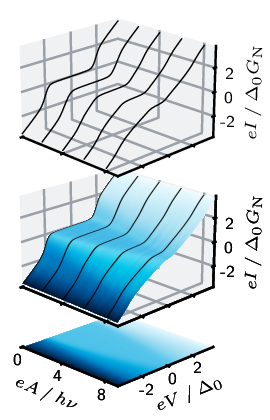

/Users/oliver/Documents/cryolab/dissertation-figures/tunnelbarrier/asym/irradiation/nu_7.75GHz/cal_iv/main.png

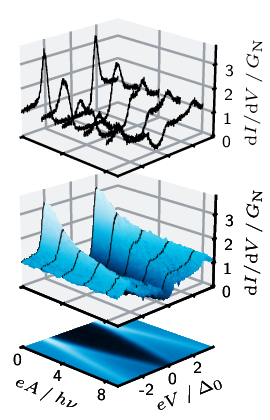

/Users/oliver/Documents/cryolab/dissertation-figures/tunnelbarrier/asym/irradiation/nu_7.75GHz/cal_didv/main.png

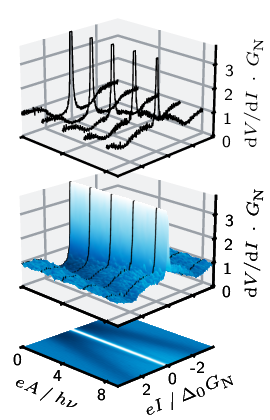

/Users/oliver/Documents/cryolab/dissertation-figures/tunnelbarrier/asym/irradiation/nu_7.75GHz/cal_dvdi/main.png

7.869999999999997


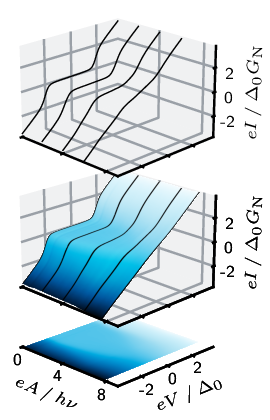

/Users/oliver/Documents/cryolab/dissertation-figures/tunnelbarrier/asym/irradiation/nu_7.87GHz/cal_iv/main.png

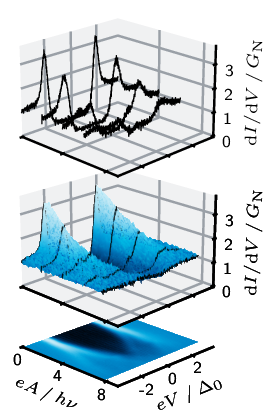

/Users/oliver/Documents/cryolab/dissertation-figures/tunnelbarrier/asym/irradiation/nu_7.87GHz/cal_didv/main.png

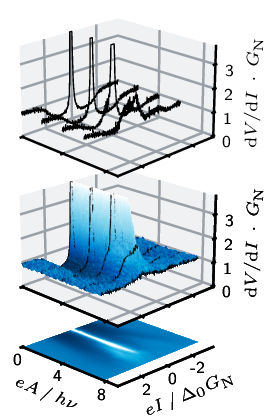

/Users/oliver/Documents/cryolab/dissertation-figures/tunnelbarrier/asym/irradiation/nu_7.87GHz/cal_dvdi/main.png

7.889999999999997


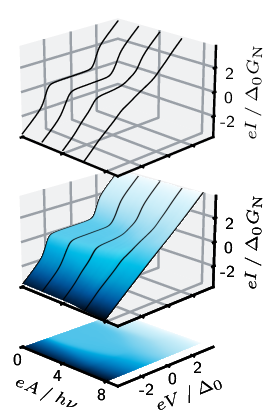

/Users/oliver/Documents/cryolab/dissertation-figures/tunnelbarrier/asym/irradiation/nu_7.89GHz/cal_iv/main.png

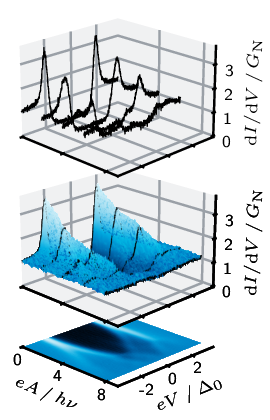

/Users/oliver/Documents/cryolab/dissertation-figures/tunnelbarrier/asym/irradiation/nu_7.89GHz/cal_didv/main.png

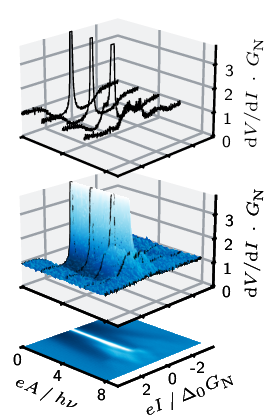

/Users/oliver/Documents/cryolab/dissertation-figures/tunnelbarrier/asym/irradiation/nu_7.89GHz/cal_dvdi/main.png

7.909999999999997


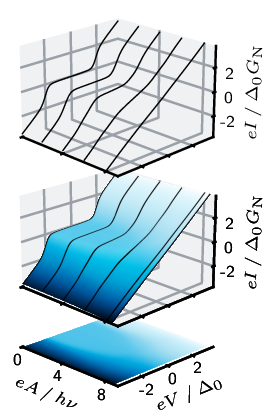

/Users/oliver/Documents/cryolab/dissertation-figures/tunnelbarrier/asym/irradiation/nu_7.91GHz/cal_iv/main.png

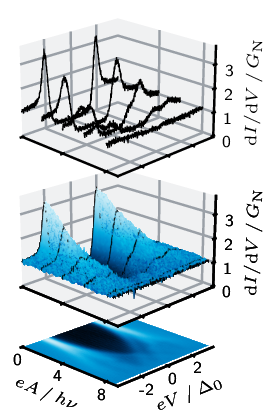

/Users/oliver/Documents/cryolab/dissertation-figures/tunnelbarrier/asym/irradiation/nu_7.91GHz/cal_didv/main.png

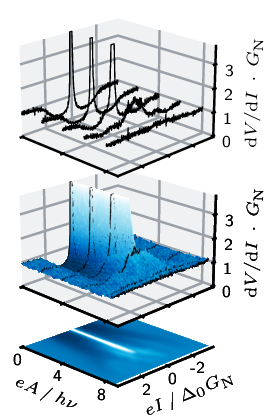

/Users/oliver/Documents/cryolab/dissertation-figures/tunnelbarrier/asym/irradiation/nu_7.91GHz/cal_dvdi/main.png

7.9599999999999955


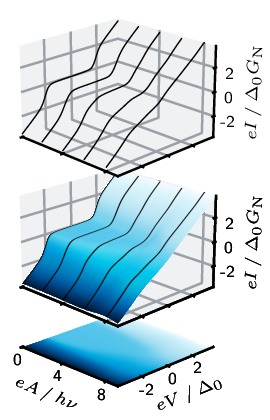

/Users/oliver/Documents/cryolab/dissertation-figures/tunnelbarrier/asym/irradiation/nu_7.96GHz/cal_iv/main.png

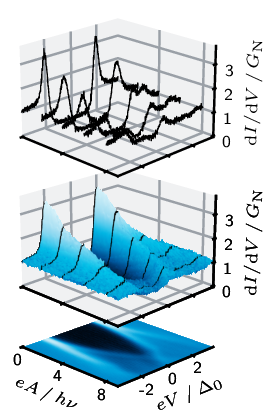

/Users/oliver/Documents/cryolab/dissertation-figures/tunnelbarrier/asym/irradiation/nu_7.96GHz/cal_didv/main.png

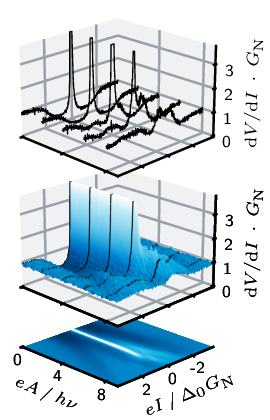

/Users/oliver/Documents/cryolab/dissertation-figures/tunnelbarrier/asym/irradiation/nu_7.96GHz/cal_dvdi/main.png

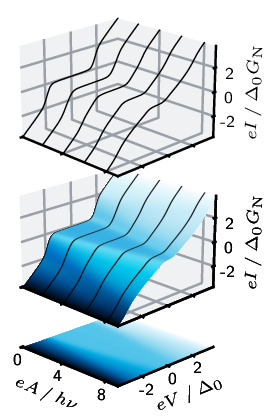

/Users/oliver/Documents/cryolab/dissertation-figures/tunnelbarrier/asym/irradiation/nu_7.96GHz/sim_iv/main.png

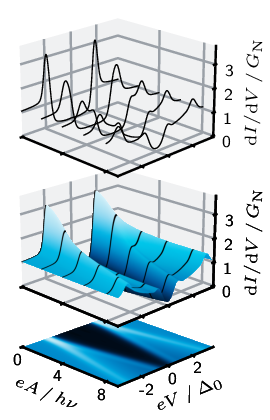

/Users/oliver/Documents/cryolab/dissertation-figures/tunnelbarrier/asym/irradiation/nu_7.96GHz/sim_didv/main.png

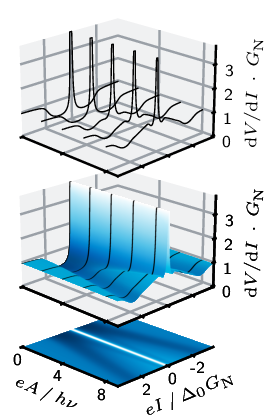

/Users/oliver/Documents/cryolab/dissertation-figures/tunnelbarrier/asym/irradiation/nu_7.96GHz/sim_dvdi/main.png

7.969999999999995


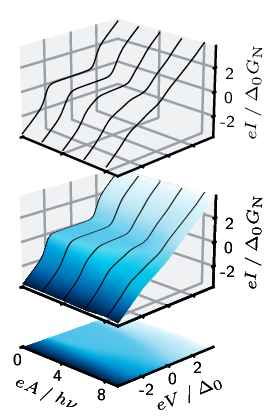

/Users/oliver/Documents/cryolab/dissertation-figures/tunnelbarrier/asym/irradiation/nu_7.97GHz/cal_iv/main.png

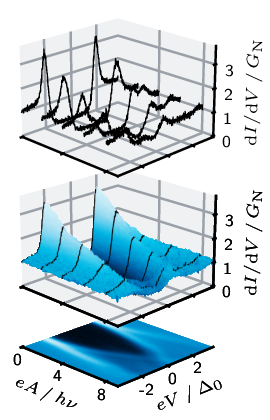

/Users/oliver/Documents/cryolab/dissertation-figures/tunnelbarrier/asym/irradiation/nu_7.97GHz/cal_didv/main.png

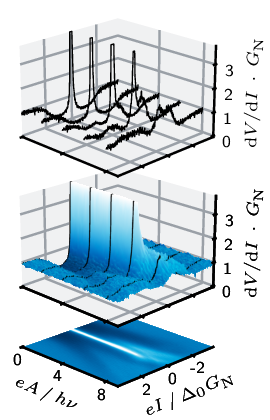

/Users/oliver/Documents/cryolab/dissertation-figures/tunnelbarrier/asym/irradiation/nu_7.97GHz/cal_dvdi/main.png

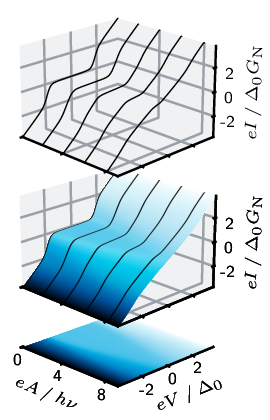

/Users/oliver/Documents/cryolab/dissertation-figures/tunnelbarrier/asym/irradiation/nu_7.97GHz/sim_iv/main.png

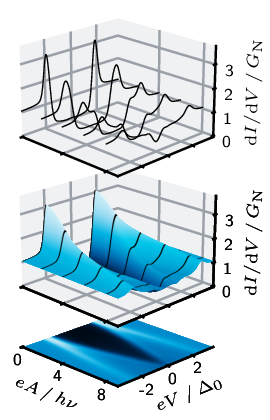

/Users/oliver/Documents/cryolab/dissertation-figures/tunnelbarrier/asym/irradiation/nu_7.97GHz/sim_didv/main.png

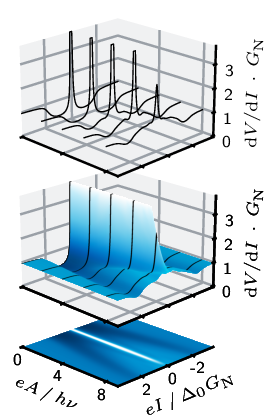

/Users/oliver/Documents/cryolab/dissertation-figures/tunnelbarrier/asym/irradiation/nu_7.97GHz/sim_dvdi/main.png

8.049999999999994


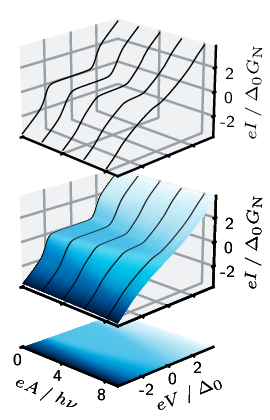

/Users/oliver/Documents/cryolab/dissertation-figures/tunnelbarrier/asym/irradiation/nu_8.05GHz/cal_iv/main.png

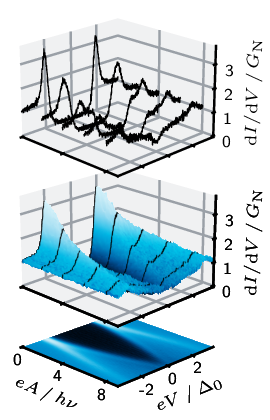

/Users/oliver/Documents/cryolab/dissertation-figures/tunnelbarrier/asym/irradiation/nu_8.05GHz/cal_didv/main.png

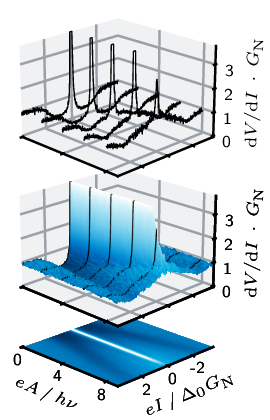

/Users/oliver/Documents/cryolab/dissertation-figures/tunnelbarrier/asym/irradiation/nu_8.05GHz/cal_dvdi/main.png

In [2]:
# calibration
from superconductivity.visuals.landscape import export_landscape_thesis

Vbins = np.linspace(-3.75, 3.75, 501)

ii = np.array([0, 12, 14, 16, 21, 22, 30])
# ii = np.array([22])

nu_GHz = np.arange(7.75, 8.05, 0.01)

for i, nui_GHz in enumerate(nu_GHz):
    if i in ii:
        print(nu_GHz[i])
        data = np.load(f"irradiation/nu_{nui_GHz:3.2f}GHz/cal.npz")

        Vbias = data["Vbias"]
        Ibias = data["Ibias"]
        Abias = data["Acal"]
        Iexp = data["Ical"]
        dGexp = data["dGcal"]
        dRexp = data["dRcal"]

        Iexp = sc.nanbin_y_over_x(Iexp, Vbias, Vbins, axis=1)
        dGexp = sc.nanbin_y_over_x(dGexp, Vbias, Vbins, axis=1)
        dRexp = sc.nanbin_y_over_x(dRexp, Vbias, Vbins, axis=1)

        exports = export_landscape_thesis(
            Vbias=Vbins,
            Abias=Abias,
            Ibias=Vbins,
            Iexp=Iexp,
            dGexp=dGexp,
            dRexp=dRexp,
            waterfall_traces=[0.0, 2.0, 4.0, 6.0, 8.0],
            name="cal",
            sub_dir=f"tunnelbarrier/asym/irradiation/nu_{nui_GHz:3.2f}GHz",
            surface_points=(300, 100),
            surface_center_width_y=0,
            Vbiaslim=(-3.75, 3.75),
            Abiaslim=(0, 9.0),
            Ibiaslim=(-3.75, 3.75),
            Ilim=(-3.75, 3.75),
            dRlim=(-0.05, 3.75),
            dGlim=(-0.05, 3.75),
        )

    if i in [21, 22]:
        data = np.load(f"irradiation/nu_{nui_GHz:3.2f}GHz/sim.npz")

        Vbias = data["Vbias"]
        Ibias = data["Ibias"]
        Abias = data["Abias"]
        Iexp = data["Isim"]
        dGexp = data["dGsim"]
        dRexp = data["dRsim"]

        exports = export_landscape_thesis(
            Vbias=Vbins,
            Abias=Abias,
            Ibias=Vbins,
            Iexp=Iexp,
            dGexp=dGexp,
            dRexp=dRexp,
            waterfall_traces=[0.0, 2.0, 4.0, 6.0, 8.0],
            name="sim",
            sub_dir=f"tunnelbarrier/asym/irradiation/nu_{nui_GHz:3.2f}GHz",
            surface_points=(300, 100),
            surface_center_width_y=0,
            Vbiaslim=(-3.75, 3.75),
            Abiaslim=(0, 9.0),
            Ibiaslim=(-3.75, 3.75),
            Ilim=(-3.75, 3.75),
            dRlim=(-0.05, 3.75),
            dGlim=(-0.05, 3.75),
        )

# Single IV

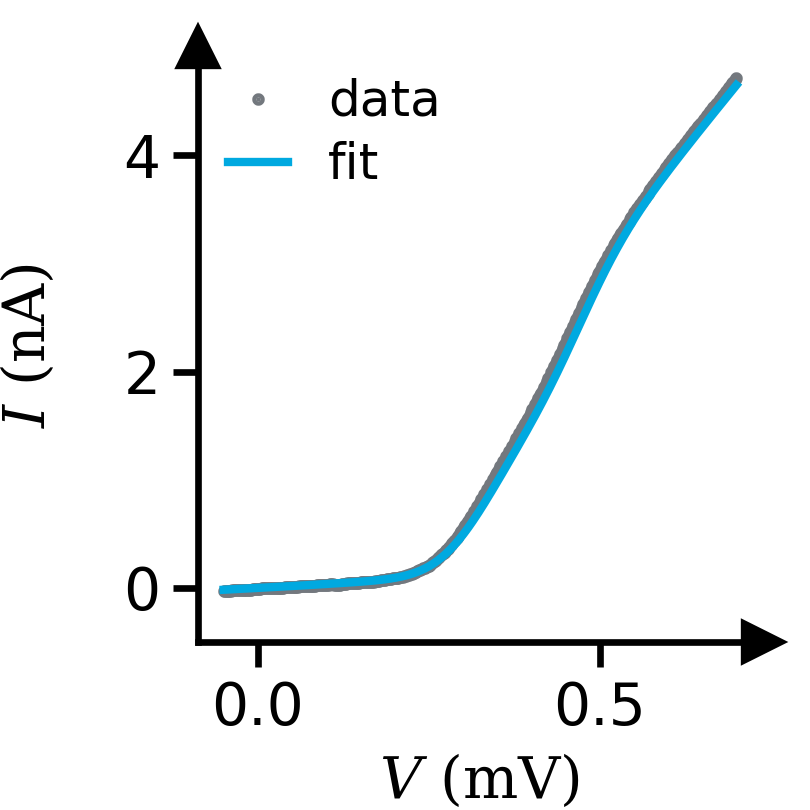

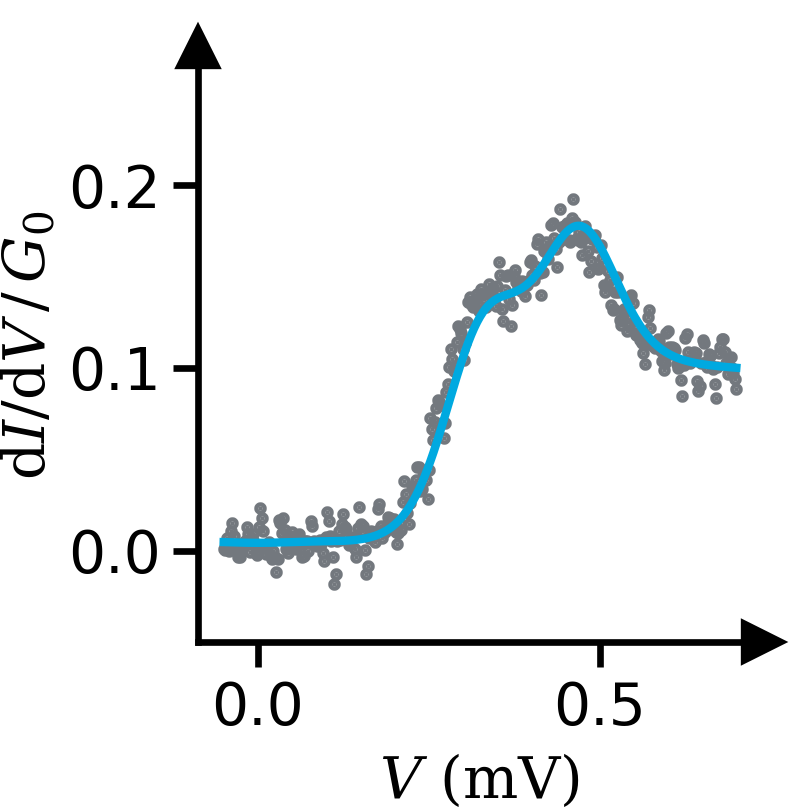

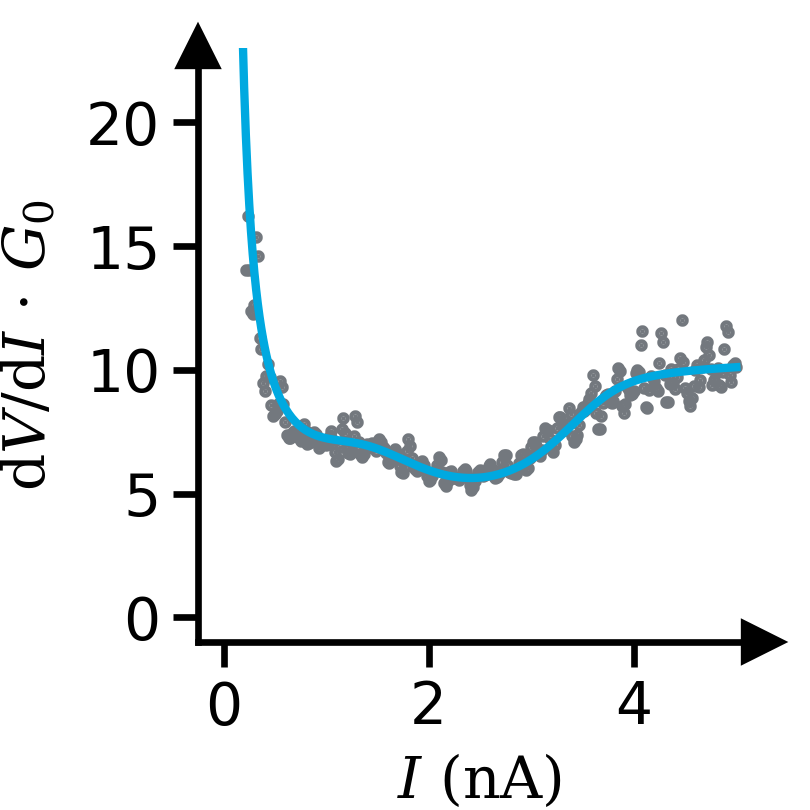

In [2]:
# Single IV for inital fit

outdir = "irradiation/single-fit"

# load data
data = np.load("irradiation/singleiv-fit.npz")

V_mV = data["Vbias_mV"]
Iexp_nA = data["Iexp_nA"]
Ifit_nA = data["Ifit_nA"]

dGexp_G0 = np.gradient(Iexp_nA, V_mV) / sc.G0_muS
dGfit_G0 = np.gradient(Ifit_nA, V_mV) / sc.G0_muS
dRexp_R0 = np.gradient(V_mV, Iexp_nA) * sc.G0_muS
dRfit_R0 = np.gradient(V_mV, Ifit_nA) * sc.G0_muS

Vbins_mV = np.linspace(-0.05, 0.7, 353)
Ibins_nA = np.linspace(0, 5, 301)

from superconductivity.utilities.functions.upsampling import upsample

dRexp_R0 = sc.bin_y_over_x(
    upsample(dRexp_R0, N_up=100), upsample(Iexp_nA, N_up=100), Ibins_nA
)
dRfit_R0 = sc.bin_y_over_x(
    upsample(dRfit_R0, N_up=100), upsample(Ifit_nA, N_up=100), Ibins_nA
)
dGexp_G0 = sc.bin_y_over_x(
    upsample(dGexp_G0, N_up=100), upsample(V_mV, N_up=100), Vbins_mV
)
dGfit_G0 = sc.bin_y_over_x(
    upsample(dGfit_G0, N_up=100), upsample(V_mV, N_up=100), Vbins_mV
)
Iexp_nA = sc.bin_y_over_x(
    upsample(Iexp_nA, N_up=100), upsample(V_mV, N_up=100), Vbins_mV
)
Ifit_nA = sc.bin_y_over_x(
    upsample(Ifit_nA, N_up=100), upsample(V_mV, N_up=100), Vbins_mV
)
V_mV = Vbins_mV

# iv
fig, ax = sc.get_figure(figsize=(1.35, 1.35), padding=(0.25, 0.2))

ax.plot(
    Vbins_mV,
    Iexp_nA,
    ".",
    label="data",
    color=sc.seegrau100,
)
ax.plot(
    Vbins_mV,
    Ifit_nA,
    label="fit",
    color=sc.seeblau100,
)

ax.legend(
    # title="$\\alpha_q = $",
    handlelength=1.2,
    loc="upper left",
    frameon=False,
    fontsize=6,
    title_fontsize=6,
    ncols=1,
    columnspacing=0.8,
    borderpad=0.1,  # reduces padding inside the legend box
    labelspacing=0.3,  # reduces vertical spacing between items
    handletextpad=0.8,  # reduces spacing between line and label
    # bbox_to_anchor=(1.1, 1.1),
)
ax.set_ylim(-0.5, 4.99)
ax.set_yticks([0, 2, 4])

xlabel = "$V\\ \\mathrm{(mV)}$"
ylabel = "$I\\ \\mathrm{(nA)}$"
title = f"tunnelbarrier/asym/{outdir}/iv"

sc.theory_layout(fig, ax, title, xlabel, ylabel)
plt.show()
# didv
fig, ax = sc.get_figure(figsize=(1.35, 1.35), padding=(0.25, 0.2))

ax.plot(
    Vbins_mV,
    dGexp_G0,
    ".",
    label="data",
    color=sc.seegrau100,
)
ax.plot(
    Vbins_mV,
    dGfit_G0,
    label="fit",
    color=sc.seeblau100,
)
ax.set_ylim(-0.05, 0.275)

xlabel = "$V\\ \\mathrm{(mV)}$"
ylabel = "$\\mathrm{d}I/\\mathrm{d}V\\,/\\,G_0$"
title = f"tunnelbarrier/asym/{outdir}/didv"

sc.theory_layout(fig, ax, title, xlabel, ylabel)
plt.show()
# dvdi
fig, ax = sc.get_figure(figsize=(1.35, 1.35), padding=(0.25, 0.2))

ax.plot(
    Ibins_nA,
    dRexp_R0,
    ".",
    label="data",
    color=sc.seegrau100,
)
ax.plot(
    Ibins_nA,
    dRfit_R0,
    label="data",
    color=sc.seeblau100,
)

ax.set_ylim(-1, 23)

ylabel = "$\\mathrm{d}V/\\mathrm{d}I\\,\\cdot\\,G_0$"
xlabel = "$I\\ \\mathrm{(nA)}$"
title = f"tunnelbarrier/asym/{outdir}/dvdi"

sc.theory_layout(fig, ax, title, xlabel, ylabel)
plt.show()

29 55 6
22 72


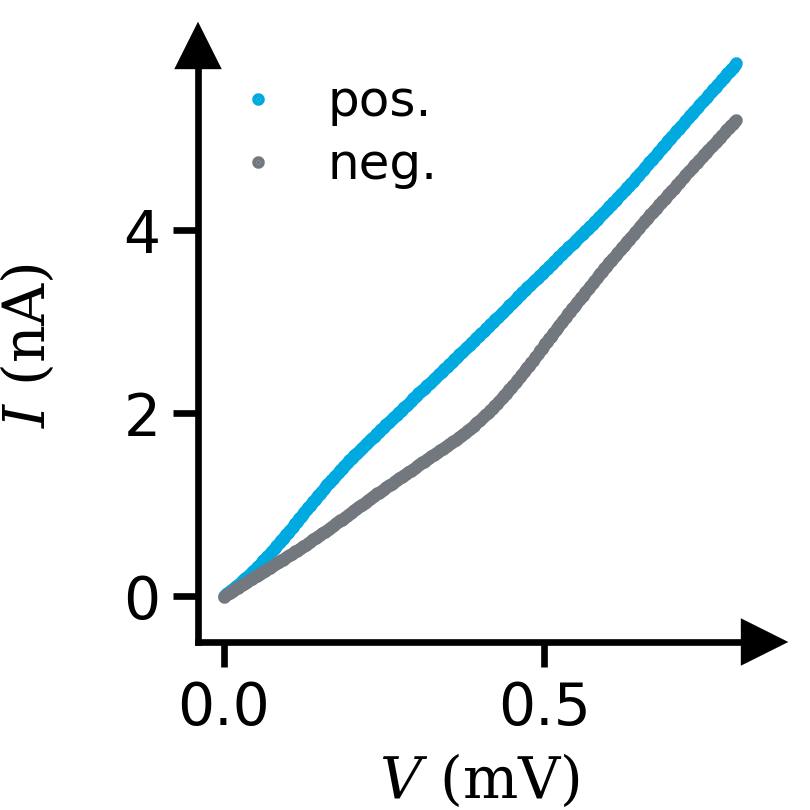

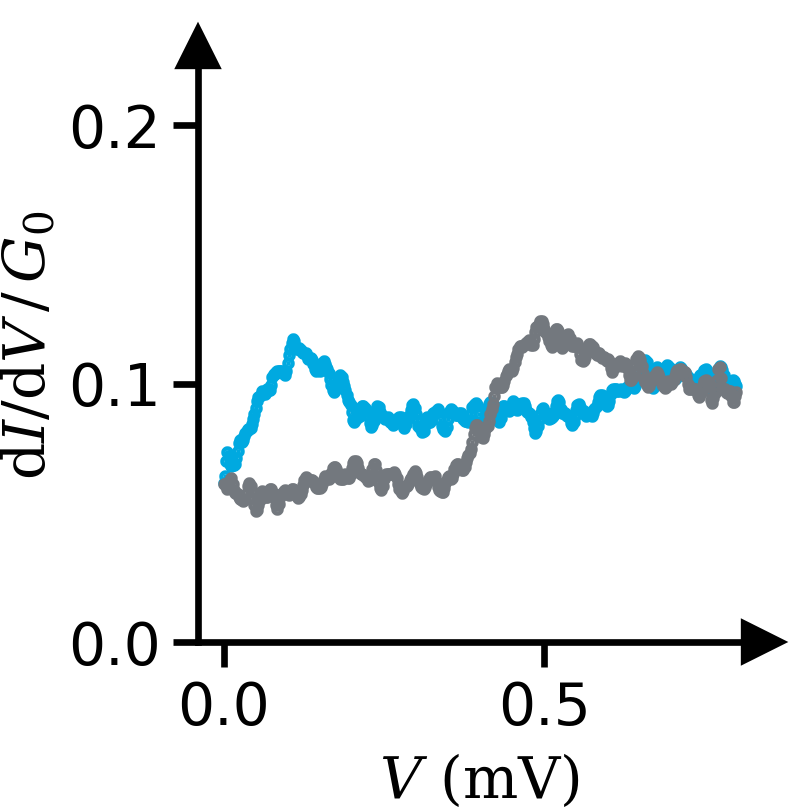

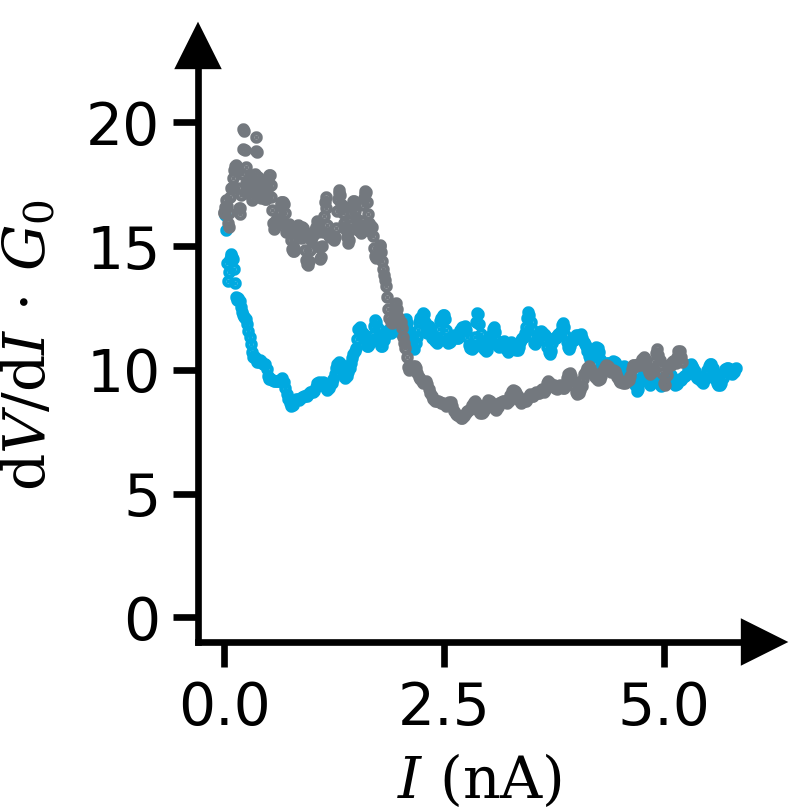

In [3]:
# Single IV for showcasing asymetry

outdir = "irradiation/single-asym"

data = np.load(f"irradiation/fit.npz")
Aout_mV = data["Aout_mV"]
nu_GHz = data["nu_GHz"]
AI_Aout = data["AI_Aout"]
AI = data["AI"]
AdG = data["AdG"]

i_nu, i_a, i_v = np.unravel_index(np.nanargmax(AI), AI.shape)
print(
    i_nu,
    i_a,
    i_v,
)

i_nu, i_a = np.unravel_index(np.argmax(AI_Aout), AI_Aout.shape)
print(i_nu, i_a)

Aouti_mV = Aout_mV[i_a]
nui_GHz = nu_GHz[i_nu]

data = np.load(f"irradiation/nu_{nui_GHz:.2f}GHz/eva.npz")

Vbias_mV = data["Vbias_mV"]
Iexp_nA = data["Iexp_nA"][i_a, :]
Tbath_K = data["Tbath_K"]

Iexp_nA = savgol_filter(Iexp_nA, window_length=15, polyorder=0)

Vbins_mV = np.linspace(-0.0, 0.8, 401)
Ipos_nA = sc.bin_y_over_x(
    upsample(Iexp_nA, N_up=100), upsample(Vbias_mV, N_up=100), Vbins_mV
)
Ineg_nA = -np.flip(
    sc.bin_y_over_x(
        upsample(Iexp_nA, N_up=100), upsample(Vbias_mV, N_up=100), -np.flip(Vbins_mV)
    )
)
dGpos_G0 = np.gradient(Ipos_nA, Vbins_mV) / sc.G0_muS
dGneg_G0 = np.gradient(Ineg_nA, Vbins_mV) / sc.G0_muS
dRpos_R0 = np.gradient(Vbins_mV, Ipos_nA) * sc.G0_muS
dRneg_R0 = np.gradient(Vbins_mV, Ineg_nA) * sc.G0_muS

# iv
fig, ax = sc.get_figure(figsize=(1.35, 1.35), padding=(0.25, 0.2))

ax.plot(
    Vbins_mV,
    Ipos_nA,
    ".",
    label="pos.",
    color=sc.seeblau100,
)
ax.plot(
    Vbins_mV,
    Ineg_nA,
    ".",
    label="neg.",
    color=sc.seegrau100,
)

ax.legend(
    # title="$\\alpha_q = $",
    handlelength=1.2,
    loc="upper left",
    frameon=False,
    fontsize=6,
    title_fontsize=6,
    ncols=1,
    columnspacing=0.8,
    borderpad=0.1,  # reduces padding inside the legend box
    labelspacing=0.3,  # reduces vertical spacing between items
    handletextpad=0.8,  # reduces spacing between line and label
    # bbox_to_anchor=(1.1, 1.1),
)
ax.set_ylim(-0.5, 5.99)
ax.set_yticks([0, 2, 4])

xlabel = "$V\\ \\mathrm{(mV)}$"
ylabel = "$I\\ \\mathrm{(nA)}$"
title = f"tunnelbarrier/asym/{outdir}/iv"

sc.theory_layout(fig, ax, title, xlabel, ylabel)
# didv
fig, ax = sc.get_figure(figsize=(1.35, 1.35), padding=(0.25, 0.2))

ax.plot(
    Vbins_mV,
    dGpos_G0,
    ".",
    label="pos.",
    color=sc.seeblau100,
)
ax.plot(
    Vbins_mV,
    dGneg_G0,
    ".",
    label="neg.",
    color=sc.seegrau100,
)
ax.set_ylim(0, 0.23)
ax.set_yticks([0, 0.1, 0.2])

xlabel = "$V\\ \\mathrm{(mV)}$"
ylabel = "$\\mathrm{d}I/\\mathrm{d}V\\,/\\,G_0$"
title = f"tunnelbarrier/asym/{outdir}/didv"

sc.theory_layout(fig, ax, title, xlabel, ylabel)
plt.show()
# dvdi
fig, ax = sc.get_figure(figsize=(1.35, 1.35), padding=(0.25, 0.2))

ax.plot(
    Ipos_nA,
    dRpos_R0,
    ".",
    label="data",
    color=sc.seeblau100,
)
ax.plot(
    Ineg_nA,
    dRneg_R0,
    ".",
    label="data",
    color=sc.seegrau100,
)

ax.set_ylim(-1, 23)

ylabel = "$\\mathrm{d}V/\\mathrm{d}I\\,\\cdot\\,G_0$"
xlabel = "$I\\ \\mathrm{(nA)}$"
title = f"tunnelbarrier/asym/{outdir}/dvdi"

sc.theory_layout(fig, ax, title, xlabel, ylabel)
plt.show()

29 55 6
22 72
720.0 0.9177028241758243


/var/folders/kc/8fnzl3f94vxgl8w4wm3wfvk80000gn/T/ipykernel_78287/2878183961.py:54: RuntimeWarning: divide by zero encountered in divide
  (Ipos_nA - Ineg_nA) / np.abs(Ipos_nA + Ineg_nA),


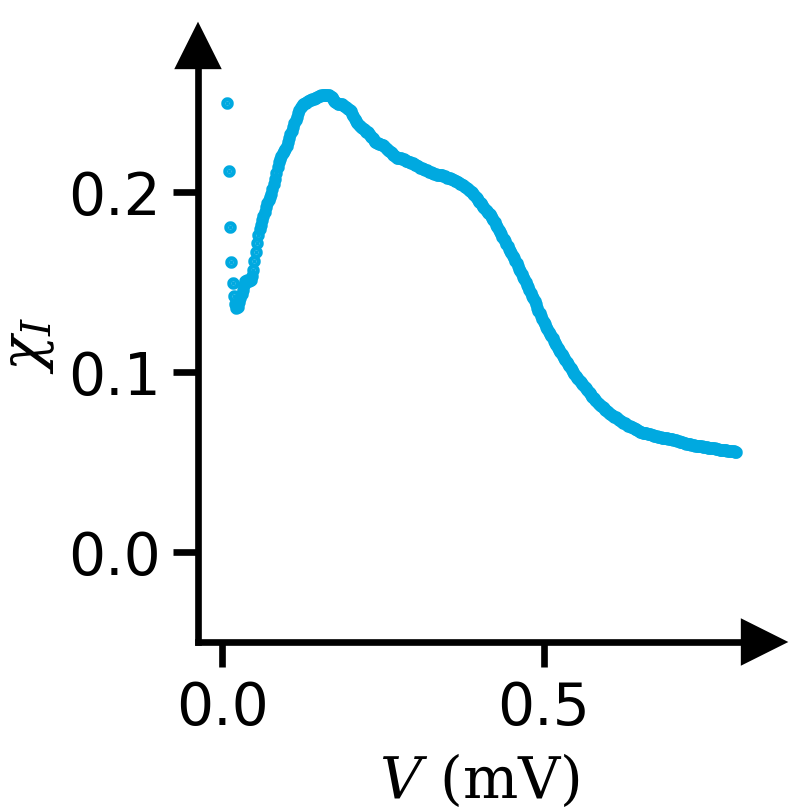

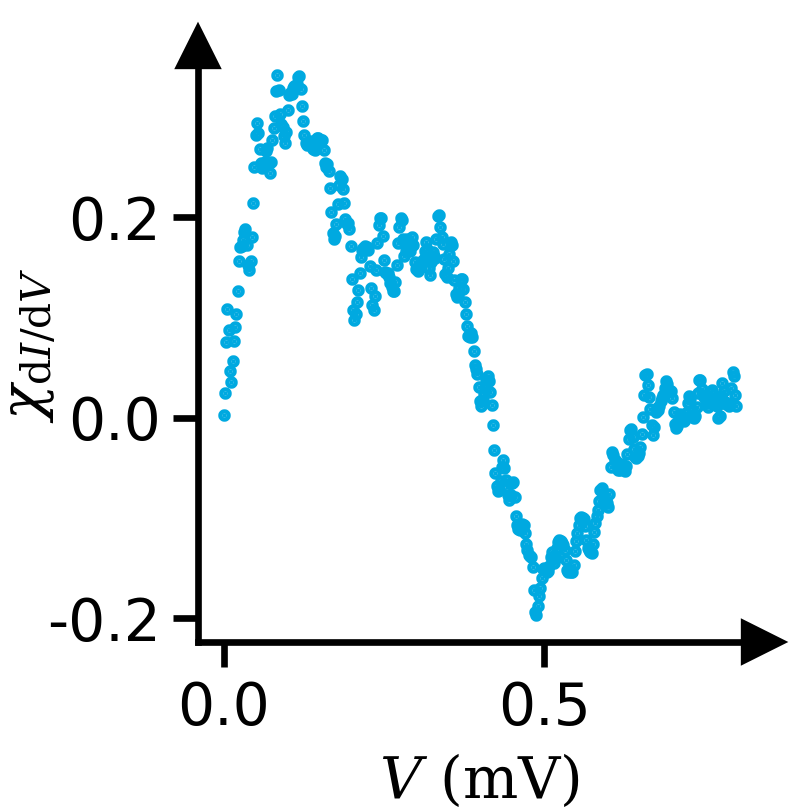

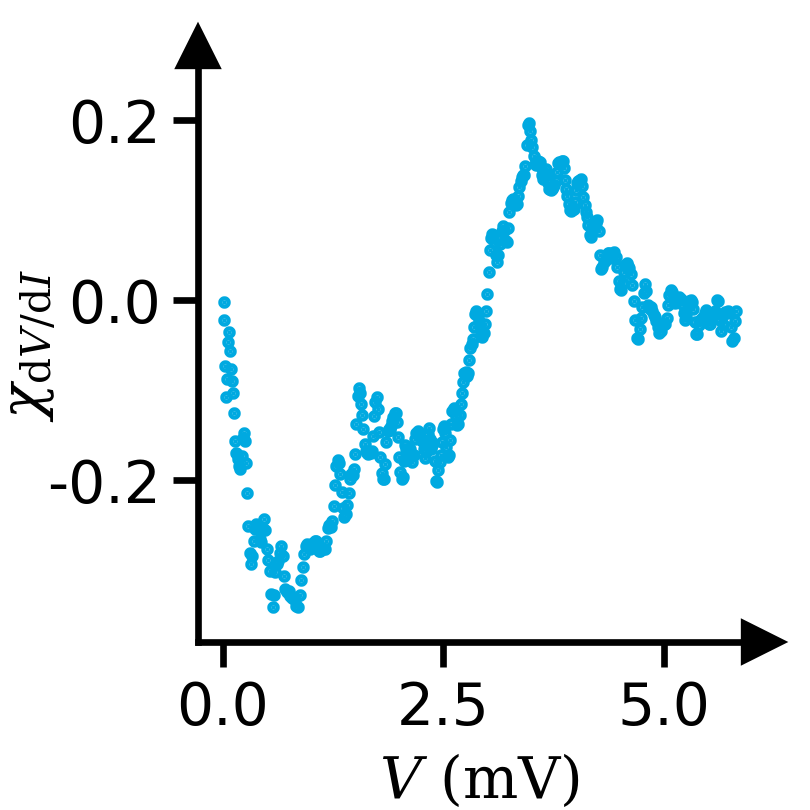

In [4]:
# Single IV for showcasing asymetry

outdir = "irradiation/single-asym-rect"

data = np.load(f"irradiation/fit.npz")
Aout_mV = data["Aout_mV"]
nu_GHz = data["nu_GHz"]
AI_Aout = data["AI_Aout"]
AI = data["AI"]
AdG = data["AdG"]

i_nu, i_a, i_v = np.unravel_index(np.nanargmax(AI), AI.shape)
print(
    i_nu,
    i_a,
    i_v,
)

i_nu, i_a = np.unravel_index(np.argmax(AI_Aout), AI_Aout.shape)
print(i_nu, i_a)

Aouti_mV = Aout_mV[i_a]
nui_GHz = nu_GHz[i_nu]

data = np.load(f"irradiation/nu_{nui_GHz:.2f}GHz/eva.npz")

Vbias_mV = data["Vbias_mV"]
Iexp_nA = data["Iexp_nA"][i_a, :]
Tbath_K = data["Tbath_K"][i_a]

print(Aouti_mV, Tbath_K)

Iexp_nA = savgol_filter(Iexp_nA, window_length=15, polyorder=0)

Vbins_mV = np.linspace(-0.0, 0.8, 401)
Ipos_nA = sc.bin_y_over_x(
    upsample(Iexp_nA, N_up=100), upsample(Vbias_mV, N_up=100), Vbins_mV
)
Ineg_nA = -np.flip(
    sc.bin_y_over_x(
        upsample(Iexp_nA, N_up=100), upsample(Vbias_mV, N_up=100), -np.flip(Vbins_mV)
    )
)
dGpos_G0 = np.gradient(Ipos_nA, Vbins_mV) / sc.G0_muS
dGneg_G0 = np.gradient(Ineg_nA, Vbins_mV) / sc.G0_muS
dRpos_R0 = np.gradient(Vbins_mV, Ipos_nA) * sc.G0_muS
dRneg_R0 = np.gradient(Vbins_mV, Ineg_nA) * sc.G0_muS

# iv
fig, ax = sc.get_figure(figsize=(1.35, 1.35), padding=(0.25, 0.2))

ax.plot(
    Vbins_mV,
    (Ipos_nA - Ineg_nA) / np.abs(Ipos_nA + Ineg_nA),
    ".",
    label="pos.",
    color=sc.seeblau100,
)
ax.set_ylim(-0.05, 0.28)
# ax.set_yticks([0, 2, 4])

xlabel = "$V\\ \\mathrm{(mV)}$"
ylabel = "$\chi_I$"
title = f"tunnelbarrier/asym/{outdir}/iv"

sc.theory_layout(fig, ax, title, xlabel, ylabel)
# didv
fig, ax = sc.get_figure(figsize=(1.35, 1.35), padding=(0.25, 0.2))

ax.plot(
    Vbins_mV,
    (dGpos_G0 - dGneg_G0) / np.abs(dGpos_G0 + dGneg_G0),
    ".",
    label="pos.",
    color=sc.seeblau100,
)
# ax.set_ylim(0, 0.23)
# ax.set_yticks([0, 0.1, 0.2])

xlabel = "$V\\ \\mathrm{(mV)}$"
ylabel = "$\chi_{\\mathrm{d}I/\\mathrm{d}V}$"
title = f"tunnelbarrier/asym/{outdir}/didv"

sc.theory_layout(fig, ax, title, xlabel, ylabel)
plt.show()
# dvdi
fig, ax = sc.get_figure(figsize=(1.35, 1.35), padding=(0.25, 0.2))

ax.plot(
    Ipos_nA,
    (dRpos_R0 - dRneg_R0) / np.abs(dRpos_R0 + dRneg_R0),
    ".",
    label="data",
    color=sc.seeblau100,
)

ax.set_ylim(-0.38, 0.28)

ylabel = "$\\mathrm{d}V/\\mathrm{d}I\\,\\cdot\\,G_0$"
ylabel = "$\chi_{\\mathrm{d}V/\\mathrm{d}I}$"
title = f"tunnelbarrier/asym/{outdir}/dvdi"

sc.theory_layout(fig, ax, title, xlabel, ylabel)
plt.show()

# Daumenkino

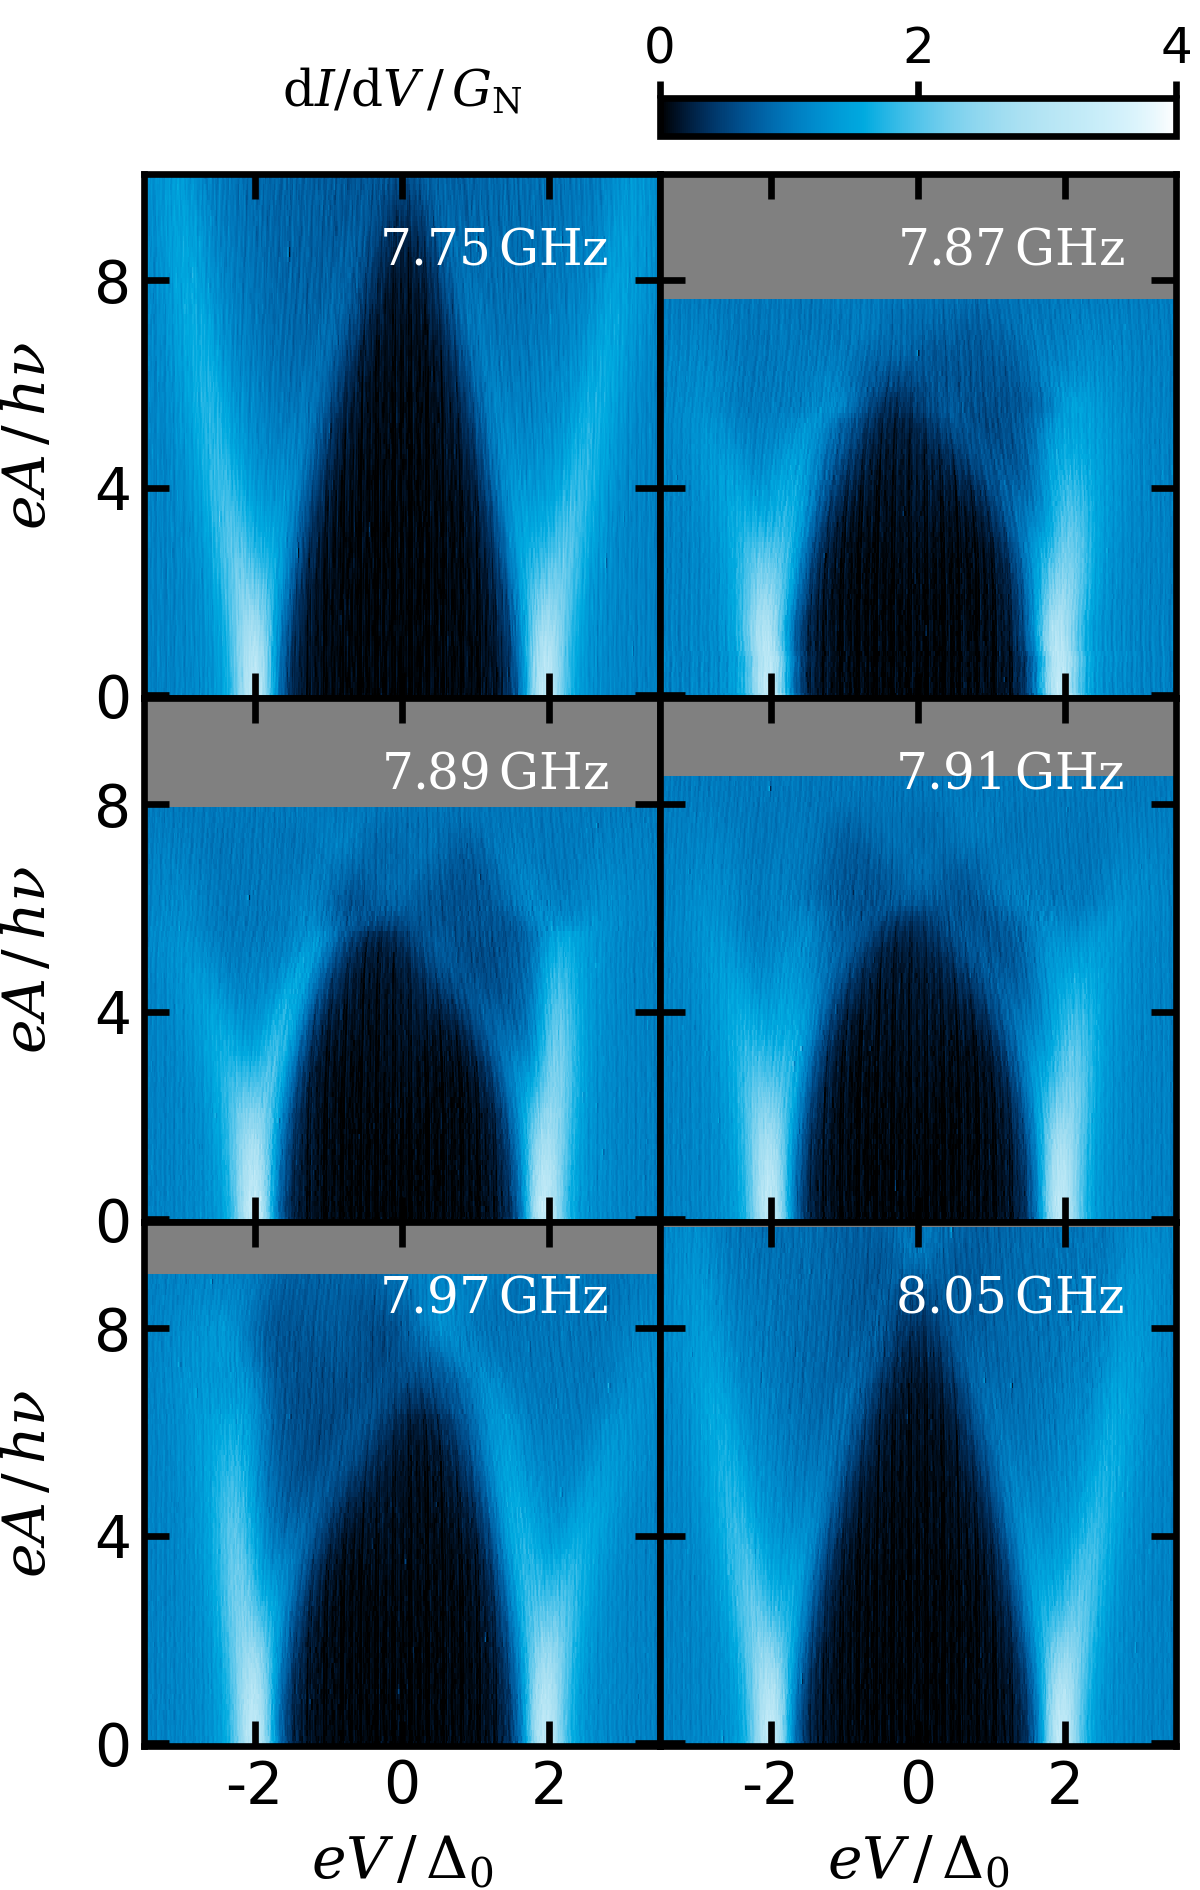

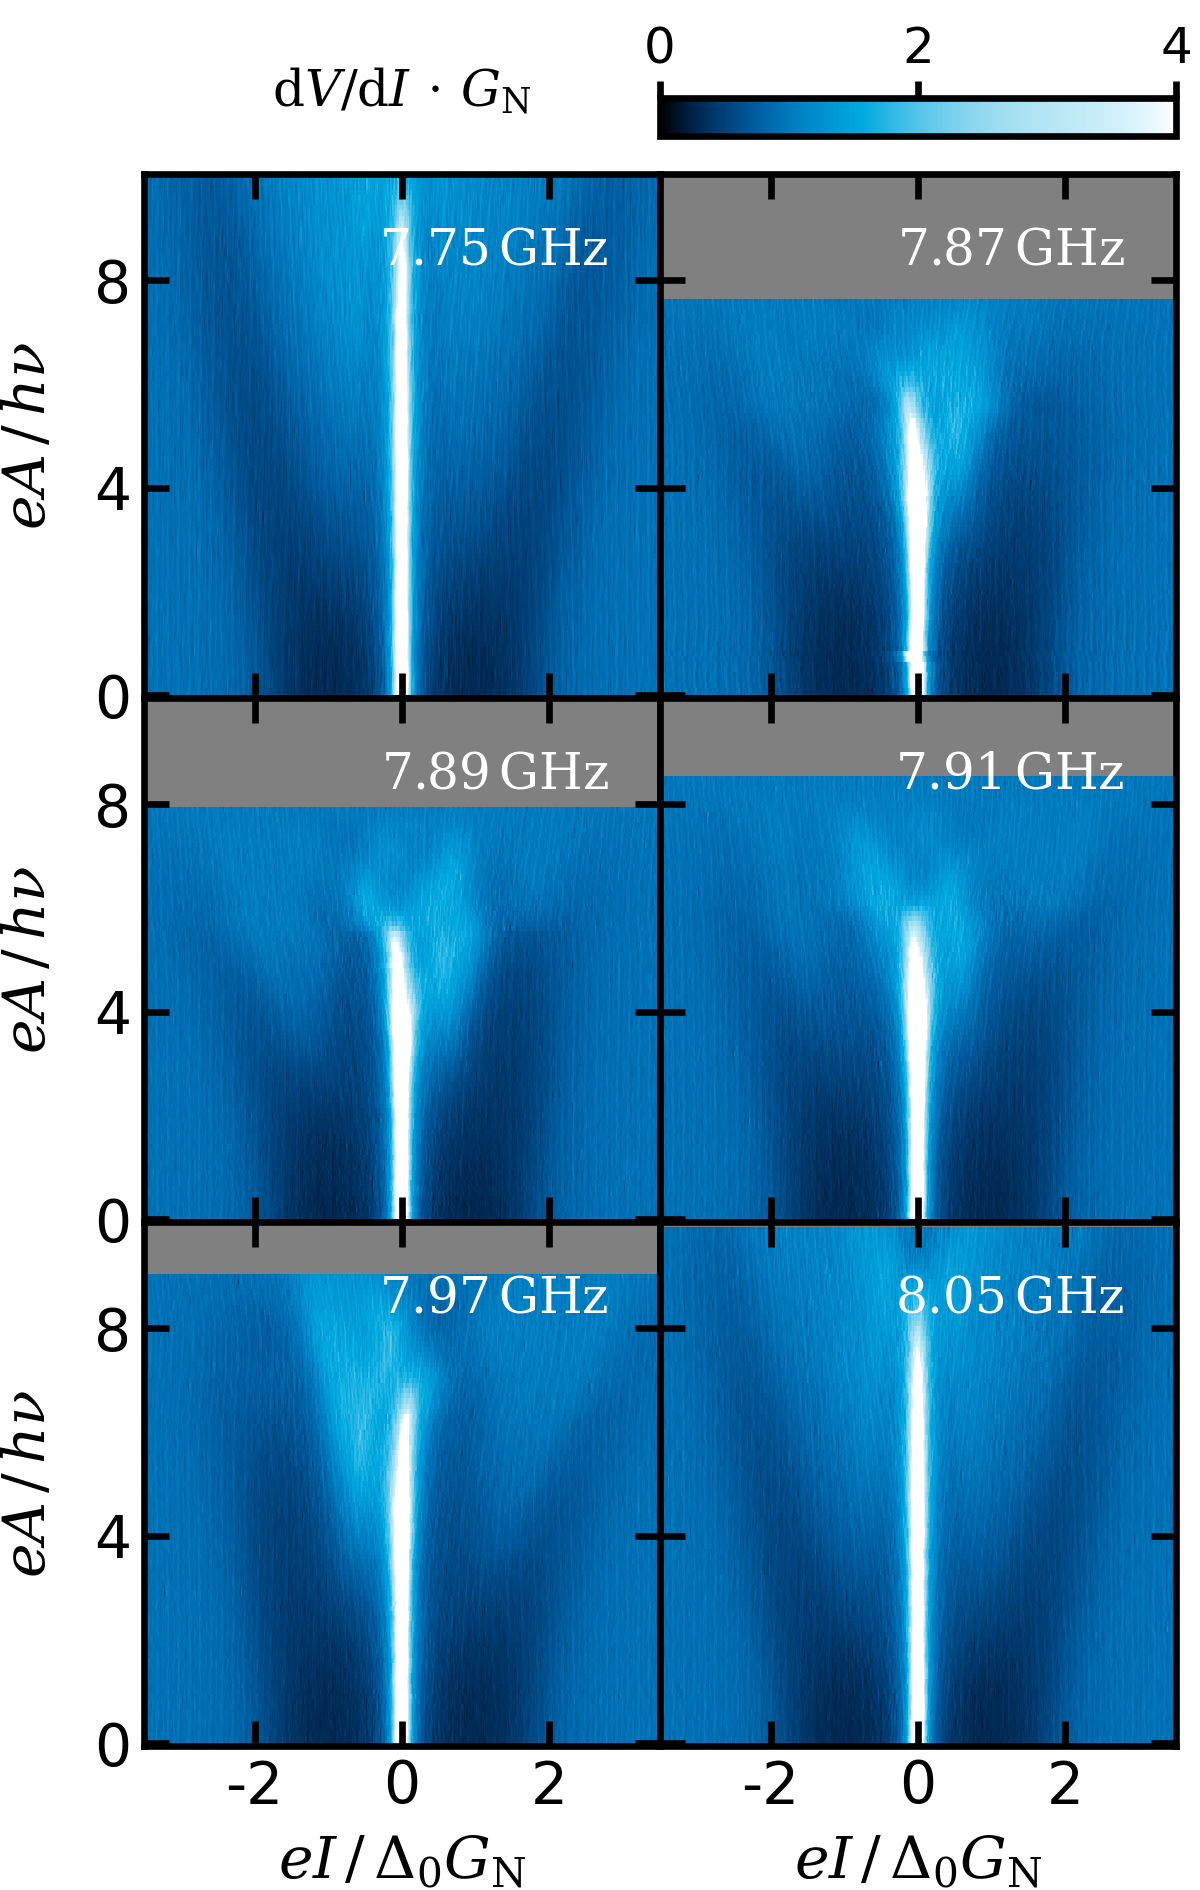

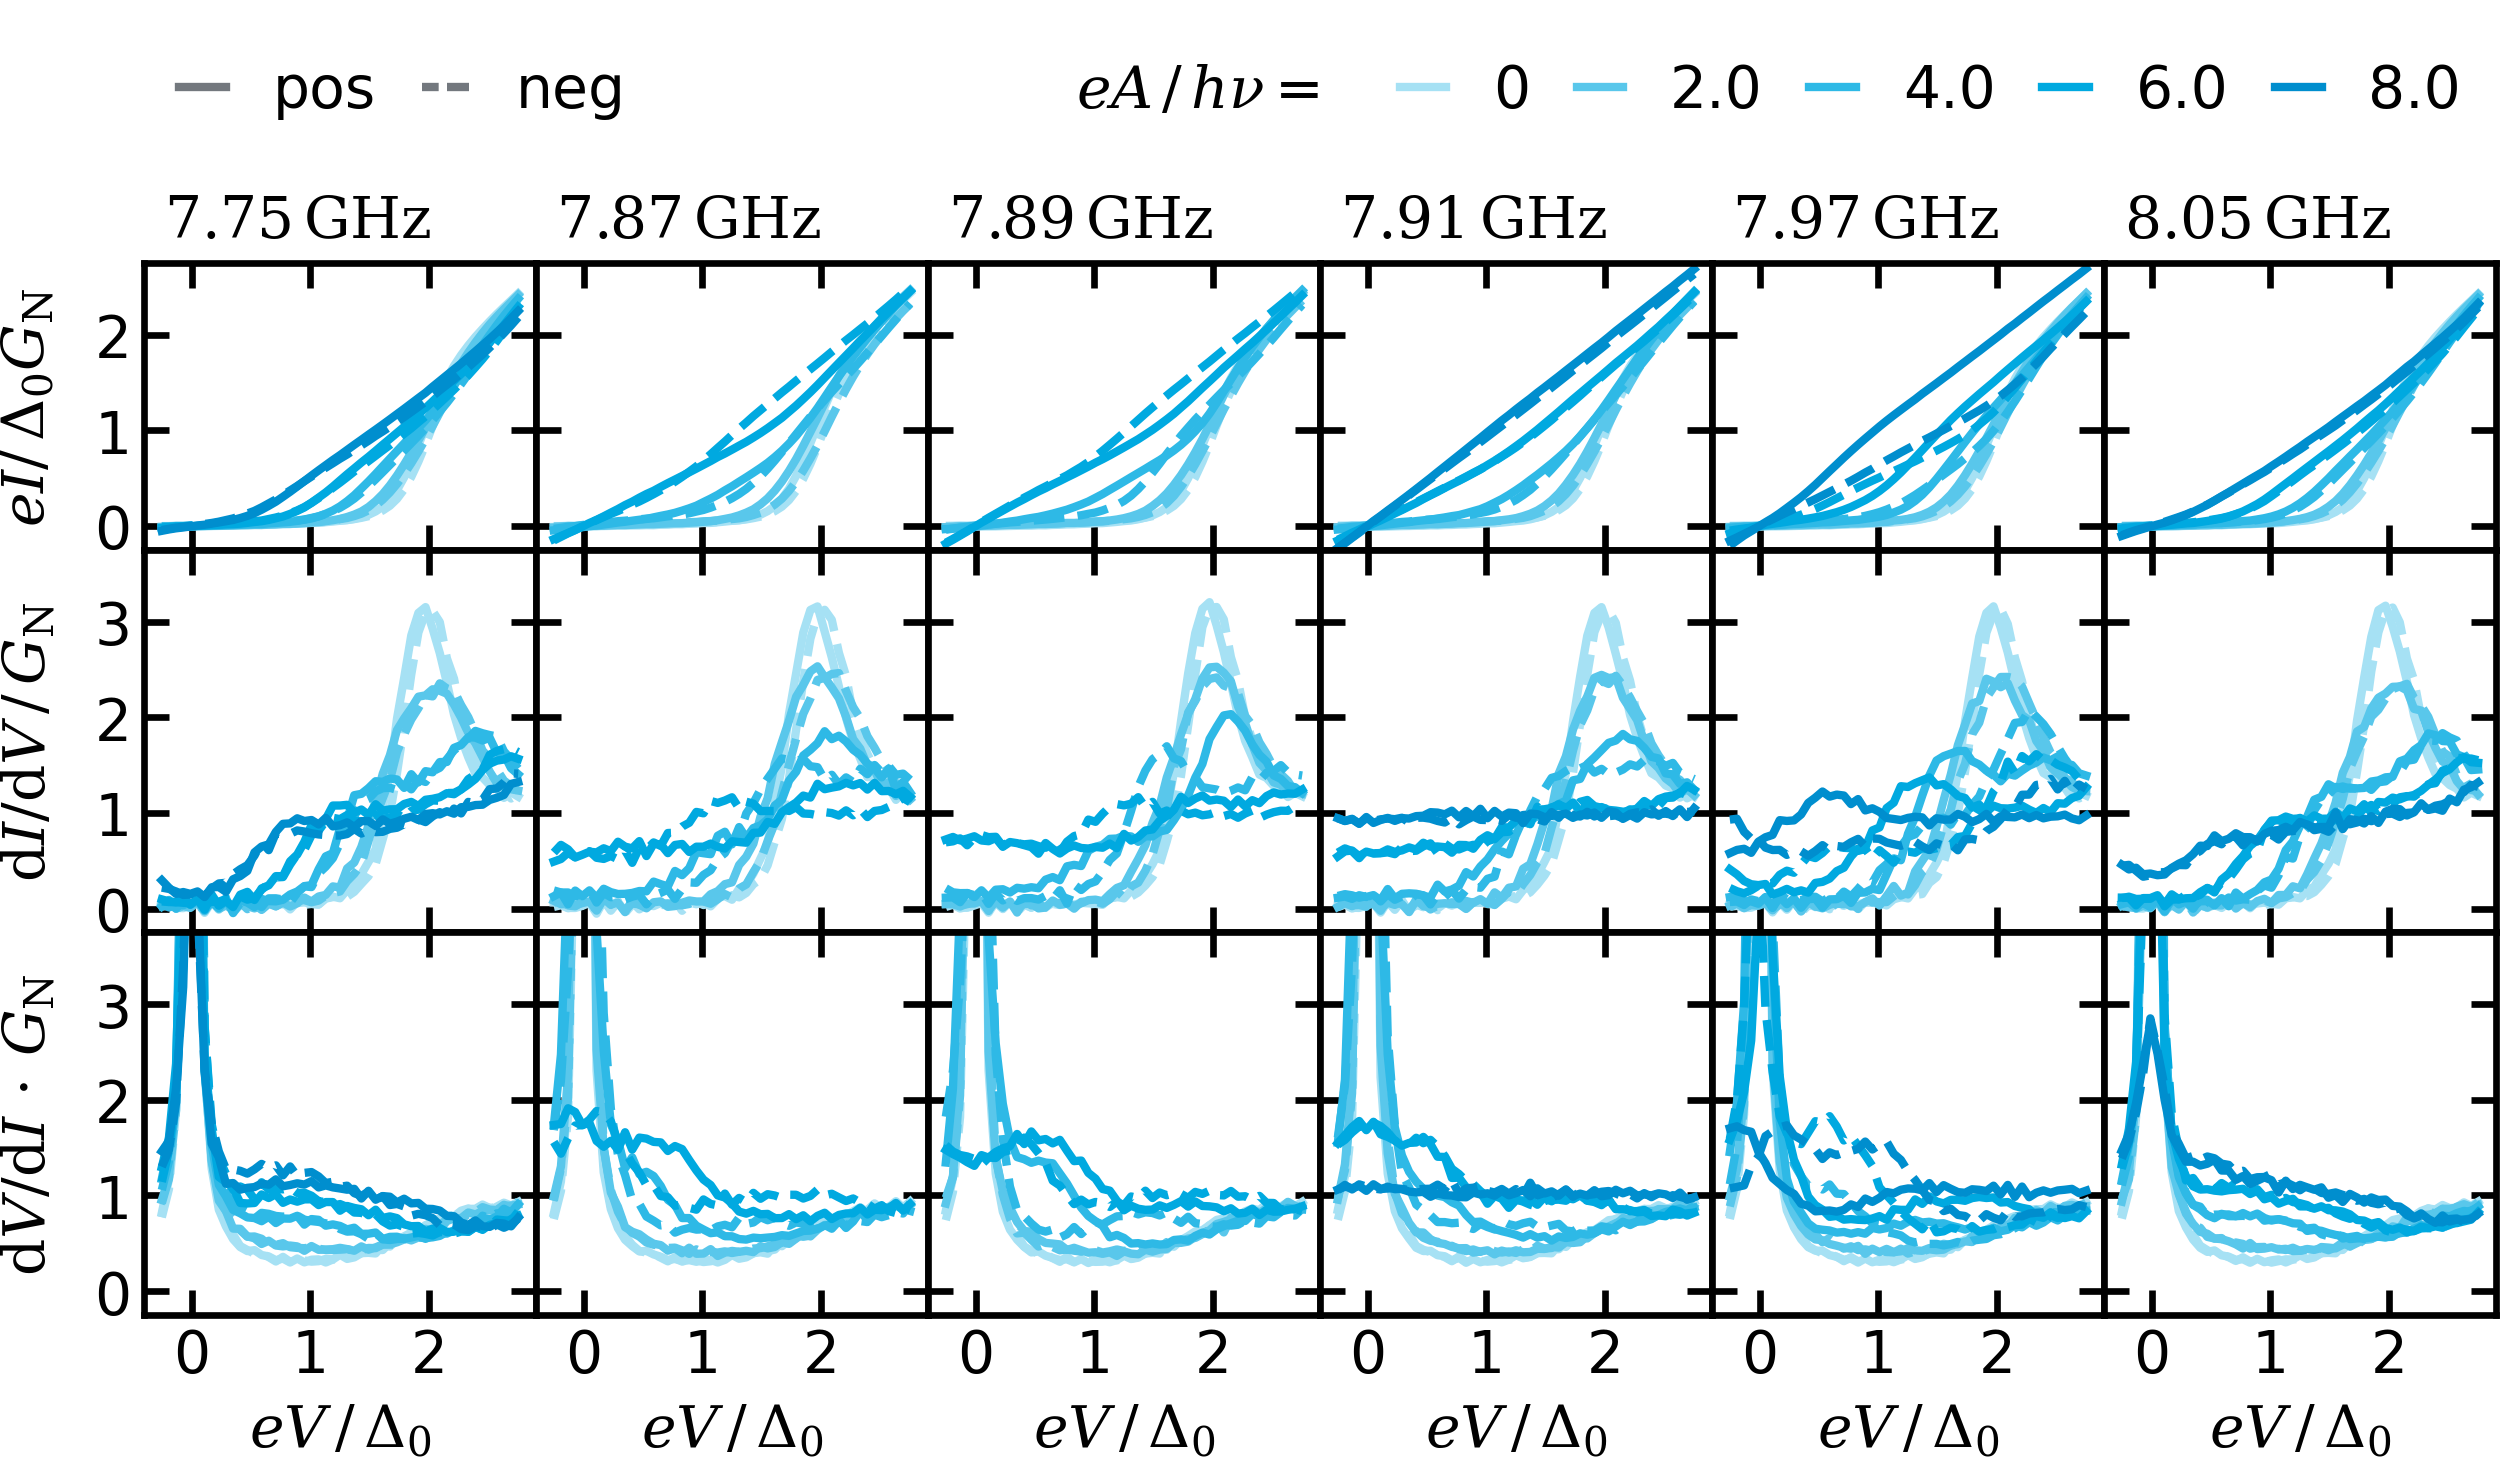

In [128]:
# progressions

from superconductivity.style.thesislayout import save_figure
from superconductivity.utilities.functions.fill_nans import fill
from superconductivity.utilities.functions.upsampling import upsample

nu_GHz = np.arange(7.75, 8.05, 0.01)
ii = np.array([0, 12, 14, 16, 22, 30])
Ainterest = [0, 2.0, 4.0, 6.0, 8.0]

Vbins = np.linspace(-0.25, 2.75, 51)
colors = [sc.seeblau35, sc.seeblau65, sc.seeblau80, sc.seeblau100, sc.seeblau120]

# region dIdV
fig, axes = sc.get_figures(
    figsize=(2.0, 3.15),
    padding=(0.2, 0.2, 0.0, 0.25),
    nrows=3,
    ncols=2,
)
for i, nui_GHz in enumerate(nu_GHz[ii]):
    datacal = np.load(f"irradiation/nu_{nui_GHz:3.2f}GHz/cal.npz")
    Vbias = datacal["Vbias"]
    Ibias = datacal["Ibias"]
    Acal = datacal["Acal"]

    Ical = datacal["Ical"]
    dGcal = datacal["dGcal"]
    dRcal = datacal["dRcal"]

    img = axes[i].pcolormesh(
        Vbias,
        Acal,
        dGcal,
        cmap=sc.get_cmap(bad="grey"),
        clim=(0, 4),
        rasterized=True,
    )
    # axes[i].set_ylim(0, 5.5)
    axes[i].set_xlim(-3.5, 3.5)
    axes[i].text(
        0.9,
        0.9,
        f"${nui_GHz:.2f}$" + "$\,\\mathrm{GHz}$",
        transform=axes[i].transAxes,
        ha="right",
        va="top",
        size=6,
        color="white",
    )

sc.daumenkino_layout(
    fig,
    axes,
    xlabel="$eV\\,/\\,\\Delta_0$",
    ylabel="$eA\\,/\\,h\\nu$",
    xticks=[-2, 0, 2],
    yticks=[0, 4, 8],
)

upper_edge = max(ax.get_position().y1 for ax in axes)
left = min(ax.get_position().x0 for ax in axes)
right = max(ax.get_position().x1 for ax in axes)

width = right - left
shrink = 0.5
new_width = width * shrink
new_left = left + 0.5 * (width - new_width)
new_left = left + (width - new_width)

cax = fig.add_axes([new_left, upper_edge + 0.02, new_width, 0.02])
cax.text(
    -0.5,
    0.5,
    "$\\mathrm{d}I/\\mathrm{d}V\\,/\\,G_\\mathrm{N}$",
    transform=cax.transAxes,
    ha="center",
    va="bottom",
    size=6,
)

cbar = fig.colorbar(
    img,
    cax=cax,
    orientation="horizontal",
)
cbar.ax.tick_params(
    labelsize=6,
    length=2,
    labelrotation=0,
    top=True,
    bottom=False,
    labeltop=True,
    labelbottom=False,
    pad=1,
)
save_figure(fig, title="tunnelbarrier/asym/irradiation/comp-img-didv/main")
# endregion

# region dVdI
fig, axes = sc.get_figures(
    figsize=(2.0, 3.15),
    padding=(0.2, 0.2, 0.0, 0.25),
    nrows=3,
    ncols=2,
)
for i, nui_GHz in enumerate(nu_GHz[ii]):
    datacal = np.load(f"irradiation/nu_{nui_GHz:3.2f}GHz/cal.npz")
    Vbias = datacal["Vbias"]
    Ibias = datacal["Ibias"]
    Acal = datacal["Acal"]

    Ical = datacal["Ical"]
    dGcal = datacal["dGcal"]
    dRcal = datacal["dRcal"]

    img = axes[i].pcolormesh(
        Ibias,
        Acal,
        dRcal,
        cmap=sc.get_cmap(bad="grey"),
        clim=(0, 4),
        rasterized=True,
    )
    # axes[i].set_ylim(0, 5.5)
    axes[i].set_xlim(-3.5, 3.5)
    axes[i].text(
        0.9,
        0.9,
        f"${nui_GHz:.2f}$" + "$\,\\mathrm{GHz}$",
        transform=axes[i].transAxes,
        ha="right",
        va="top",
        size=6,
        color="white",
    )

sc.daumenkino_layout(
    fig,
    axes,
    xlabel="$eI\\,/\\,\\Delta_0 G_\\mathrm{N}$",
    ylabel="$eA\\,/\\,h\\nu$",
    xticks=[-2, 0, 2],
    yticks=[0, 4, 8],
)

upper_edge = max(ax.get_position().y1 for ax in axes)
left = min(ax.get_position().x0 for ax in axes)
right = max(ax.get_position().x1 for ax in axes)

width = right - left
shrink = 0.5
new_width = width * shrink
new_left = left + 0.5 * (width - new_width)
new_left = left + (width - new_width)

cax = fig.add_axes([new_left, upper_edge + 0.02, new_width, 0.02])
cax.text(
    -0.5,
    0.5,
    "$\\mathrm{d}V/\\mathrm{d}I\\,\\cdot\\,G_\\mathrm{N}$",
    transform=cax.transAxes,
    ha="center",
    va="bottom",
    size=6,
)

cbar = fig.colorbar(
    img,
    cax=cax,
    orientation="horizontal",
)
cbar.ax.tick_params(
    labelsize=6,
    length=2,
    labelrotation=0,
    top=True,
    bottom=False,
    labeltop=True,
    labelbottom=False,
    pad=1,
)
save_figure(fig, title="tunnelbarrier/asym/irradiation/comp-img-dvdi/main")
# endregion

# region cuts
fig, axes = sc.get_figures(
    figsize=(4.2, 4 / 6 * 2.75 + 0.6),
    padding=(0.2, 0.2, 0.0, 0.4),
    nrows=3,
    ncols=6,
    height_ratios=(3 / 4, 1, 1),
)
for i, nui_GHz in enumerate(nu_GHz[ii]):
    datacal = np.load(f"irradiation/nu_{nui_GHz:3.2f}GHz/cal.npz")
    Vbias = datacal["Vbias"]
    Ibias = datacal["Ibias"]
    Acal = datacal["Acal"]

    Ical = datacal["Ical"]
    dGcal = datacal["dGcal"]
    dRcal = datacal["dRcal"]

    Ical_pos = sc.nanbin_y_over_x(Ical, Vbias, Vbins, axis=1)
    dGcal_pos = sc.nanbin_y_over_x(dGcal, Vbias, Vbins, axis=1)
    dRcal_pos = sc.nanbin_y_over_x(dRcal, Ibias, Vbins, axis=1)

    Ical_neg = sc.nanbin_y_over_x(-Ical, -Vbias, Vbins, axis=1)
    dGcal_neg = sc.nanbin_y_over_x(dGcal, -Vbias, Vbins, axis=1)
    dRcal_neg = sc.nanbin_y_over_x(dRcal, -Ibias, Vbins, axis=1)

    for j, ainterest in enumerate(Ainterest):
        index = np.argmin(np.abs(ainterest - Acal))
        axes[i].plot(Vbins, Ical_pos[index, :], "-", color=colors[j])
        axes[i].plot(Vbins, Ical_neg[index, :], "--", color=colors[j])
        axes[i + 6].plot(Vbins, dGcal_pos[index, :], "-", color=colors[j])
        axes[i + 6].plot(Vbins, dGcal_neg[index, :], "--", color=colors[j])
        axes[i + 12].plot(Vbins, dRcal_pos[index, :], "-", color=colors[j])
        axes[i + 12].plot(Vbins, dRcal_neg[index, :], "--", color=colors[j])

    axes[i].set_ylim(-0.25, 2.75)
    axes[i + 6].set_ylim(-0.25, 3.75)
    axes[i + 12].set_ylim(-0.25, 3.75)

    label = f"${nui_GHz:.2f}$" + "$\,\\mathrm{GHz}$"
    axes[i].text(
        0.05, 1.05, label, transform=axes[i].transAxes, ha="left", va="bottom", size=7
    )
    # axes[i + 6].text(
    #     0.1, 0.9, label, transform=axes[i + 6].transAxes, ha="left", va="top", size=7
    # )
    # axes[i + 12].text(
    #     0.9, 0.9, label, transform=axes[i + 12].transAxes, ha="right", va="top", size=7
    # )

# region legend
axes[0].plot([], [], "-", color=sc.seegrau100, label="pos")
axes[0].plot([], [], linestyle=(3, (5, 1)), color=sc.seegrau100, label="neg")
for j, ainterest in enumerate(Ainterest):
    axes[5].plot([], [], "-", color=colors[j], label=f"{ainterest}")

axes[0].legend(
    # title="$eA\\,/\\,h\\nu = $",
    handlelength=0.8,
    loc="center left",
    frameon=False,
    fontsize=7,
    title_fontsize=7,
    ncols=2,
    columnspacing=0.8,
    borderpad=0.1,  # reduces padding inside the legend box
    labelspacing=0.3,  # reduces vertical spacing between items
    handletextpad=0.8,  # reduces spacing between line and label
    bbox_to_anchor=(0.0, 1.6),
)
axes[2].text(
    1.0,
    1.6,
    "$eA\\,/\\,h\\nu=$",
    transform=axes[2].transAxes,
    ha="right",
    va="center",
    size=7,
)
axes[5].legend(
    # title="$eA\\,/\\,h\\nu$",
    handlelength=0.8,
    loc="center right",
    frameon=False,
    fontsize=7,
    title_fontsize=7,
    ncols=5,
    columnspacing=0.8,
    borderpad=0.1,  # reduces padding inside the legend box
    labelspacing=0.3,  # reduces vertical spacing between items
    handletextpad=0.8,  # reduces spacing between line and label
    bbox_to_anchor=(1.0, 1.6),
)
# endregion

sc.daumenkino_layout(
    fig,
    axes,
    title="tunnelbarrier/asym/irradiation/comp-cuts/main",
    xlabel="$eV\\,/\\,\\Delta_0$",
    ylabel=[
        "$eI/\\,\\Delta_0 G_\\mathrm{N}$",
        "$\\mathrm{d}I/\\mathrm{d}V\\,/\\,G_\\mathrm{N}$",
        "$\\mathrm{d}V/\\mathrm{d}I\\,\\cdot\\,G_\\mathrm{N}$",
    ],
    xticks=[0, 1, 2],
    yticks=([0, 1, 2], [0, 1, 2, 3], [0, 1, 2, 3]),
)
# endregion

plt.show()

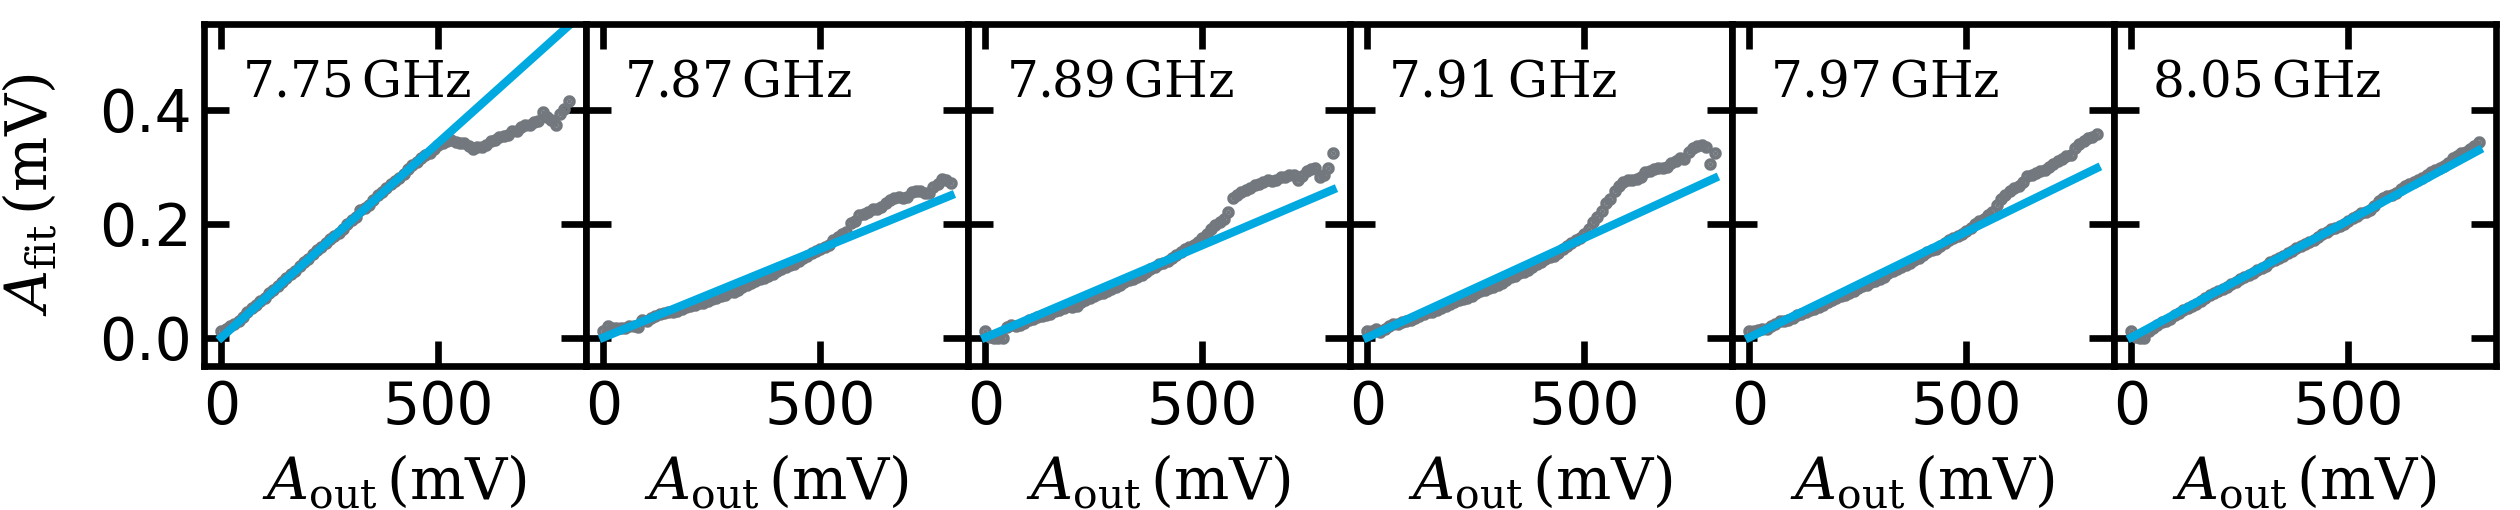

In [154]:
# Afit_mV(Aout_mV)
fig, axes = sc.get_figures(
    figsize=(4.2, 3.9 / 6 + 0.2),
    padding=(0.3, 0.2, 0.0, 0.0),
    nrows=1,
    ncols=6,
)
data = np.load("irradiation/fit.npz")
nu_GHz = data["nu_GHz"]
for i, nui_GHz in enumerate(nu_GHz[ii]):

    datafit = np.load(f"irradiation/nu_{nui_GHz:3.2f}GHz/fit_data4.npz")
    Afit_mV = datafit["value_A_mV"]

    dataexp = np.load(f"irradiation/nu_{nui_GHz:3.2f}GHz/eva.npz")
    Aout_mV = dataexp["Aout_mV"]

    etas = np.divide(
        Afit_mV,
        Aout_mV,
        out=np.full_like(Afit_mV, np.nan, dtype=float),
        where=Aout_mV != 0.0,
    )
    etas_median = np.nanmedian(etas)

    axes[i].plot(Aout_mV, Afit_mV, ".", color=sc.seegrau100)
    axes[i].plot(Aout_mV, Aout_mV * etas_median, "-", color=sc.seeblau100)
    axes[i].set_ylim(-0.05, 0.55)
    axes[i].set_xlim(-40, 840)
    axes[i].text(
        0.1,
        0.9,
        f"${nui_GHz:.2f}$" + "$\,\\mathrm{GHz}$",
        transform=axes[i].transAxes,
        ha="left",
        va="top",
        size=6,
    )

sc.daumenkino_layout(
    fig,
    axes,
    title="tunnelbarrier/asym/irradiation/control/Afit_Aout",
    xlabel="$A_\\mathrm{out}\\,(\\mathrm{mV})$",
    ylabel="$A_\\mathrm{fit}\\,(\\mathrm{mV})$",
    xticks=[0, 500],
    yticks=[0, 0.2, 0.4],
)
plt.show()

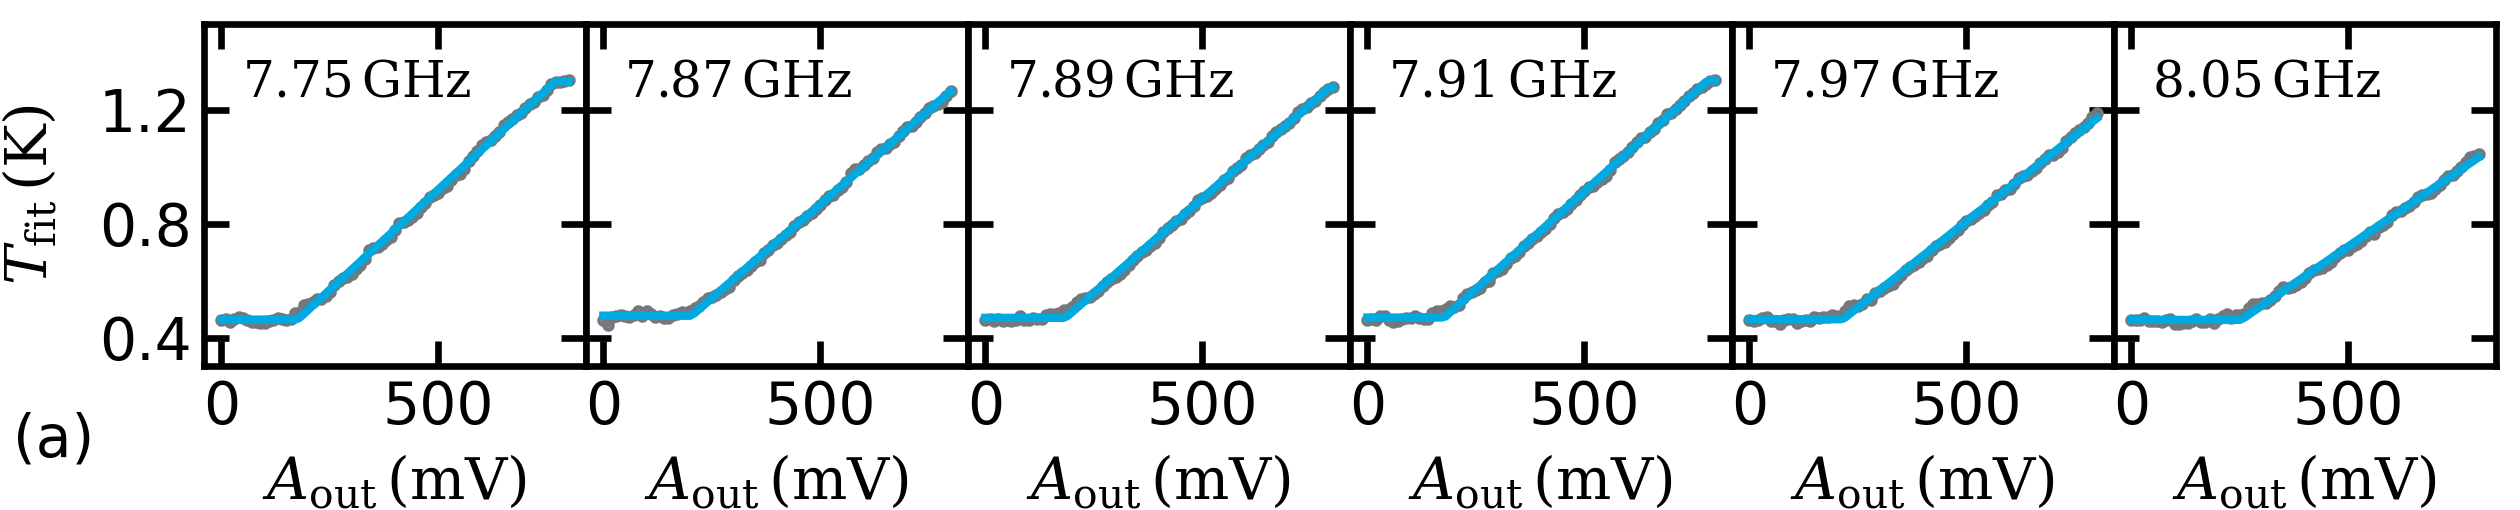

In [176]:
# Tfit_K (Aout_mV)
fig, axes = sc.get_figures(
    figsize=(4.2, 3.9 / 6 + 0.2),
    padding=(0.3, 0.2, 0.0, 0.0),
    nrows=1,
    ncols=6,
)
datafit = np.load(f"irradiation/fit.npz")
nu_GHz = datafit["nu_GHz"]
Tbase_Tfit_Aout = datafit["Tbase_Tfit_Aout"]
Tc_Tfit_Aout = datafit["Tc_Tfit_Aout"]
eta_Tfit_Aout = datafit["eta_Tfit_Aout"]
Toff_Tfit_Aout = datafit["Toff_Tfit_Aout"]

Aout_mV = np.arange(0, 810.0, 10)


def calibrate_T(Aout_mV, Tbase_K, Tc_K, eta_T, Toff_K):
    return np.clip(eta_T * Aout_mV + Toff_K, Tbase_K, Tc_K)


for i, nui_GHz in enumerate(nu_GHz[ii]):
    j = np.argmin(np.abs(nu_GHz - nui_GHz))

    datafit = np.load(f"irradiation/nu_{nui_GHz:3.2f}GHz/fit_data4.npz")
    Tfit_K = datafit["value_T_K"]

    axes[i].plot(Aout_mV, Tfit_K, ".", color=sc.seegrau100)
    axes[i].plot(
        Aout_mV,
        calibrate_T(
            Aout_mV,
            Tbase_Tfit_Aout[j],
            Tc_Tfit_Aout[j],
            eta_Tfit_Aout[j],
            Toff_Tfit_Aout[j],
        ),
        "-",
        color=sc.seeblau100,
    )
    axes[i].set_ylim(0.3, 1.5)
    axes[i].set_xlim(-40, 840)
    axes[i].text(
        0.1,
        0.9,
        f"${nui_GHz:.2f}$" + "$\,\\mathrm{GHz}$",
        transform=axes[i].transAxes,
        ha="left",
        va="top",
        size=6,
    )

axes[0].text(
    -0.5,
    -0.3,
    "(a)",
    transform=axes[0].transAxes,
    ha="left",
    va="bottom",
    size=7,
)
sc.daumenkino_layout(
    fig,
    axes,
    title="tunnelbarrier/asym/irradiation/control/Tfit_Aout",
    xlabel="$A_\\mathrm{out}\\,(\\mathrm{mV})$",
    ylabel="$T_\\mathrm{fit}\\,(\\mathrm{K})$",
    xticks=[0, 500],
    yticks=[0.4, 0.8, 1.2],
)
plt.show()

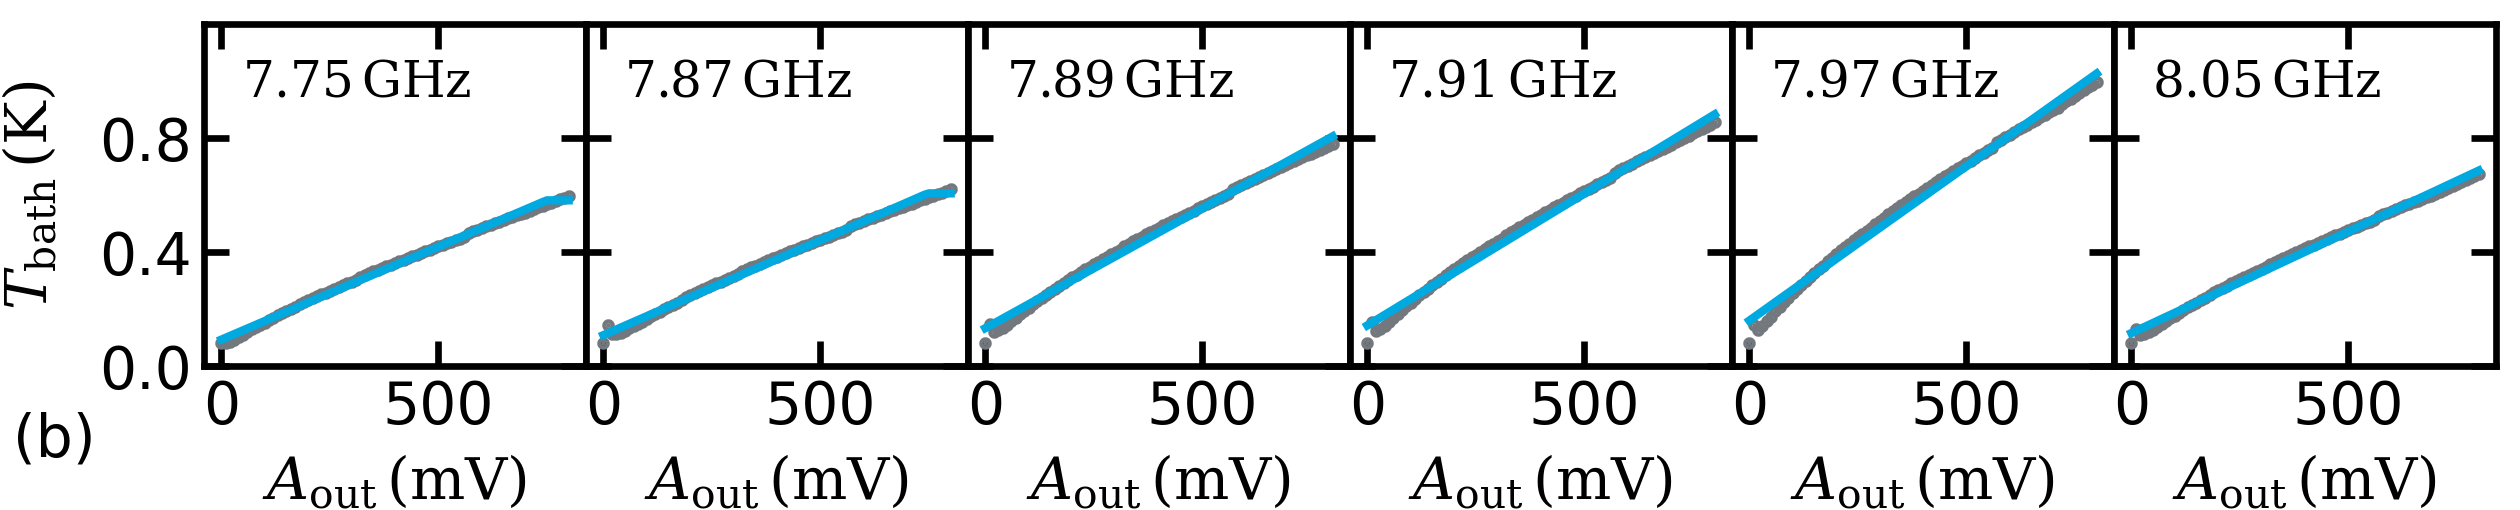

In [177]:
# Tbath_K (Aout_mV)
fig, axes = sc.get_figures(
    figsize=(4.2, 3.9 / 6 + 0.2),
    padding=(0.3, 0.2, 0.0, 0.0),
    nrows=1,
    ncols=6,
)
datafit = np.load(f"irradiation/fit.npz")
nu_GHz = datafit["nu_GHz"]
Tbase_Tbath_Aout = datafit["Tbase_Tbath_Aout"]
Tc_Tbath_Aout = datafit["Tc_Tbath_Aout"]
eta_Tbath_Aout = datafit["eta_Tbath_Aout"]
Toff_Tbath_Aout = datafit["Toff_Tbath_Aout"]

Aout_mV = np.arange(0, 810.0, 10)
for i, nui_GHz in enumerate(nu_GHz[ii]):
    j = np.argmin(np.abs(nu_GHz - nui_GHz))

    datafit = np.load(f"irradiation/nu_{nui_GHz:3.2f}GHz/eva.npz")
    Tbath_K = datafit["Tbath_K"]

    axes[i].plot(Aout_mV, Tbath_K, ".", color=sc.seegrau100)
    axes[i].plot(
        Aout_mV,
        calibrate_T(
            Aout_mV,
            Tbase_Tbath_Aout[j],
            Tc_Tbath_Aout[j],
            eta_Tbath_Aout[j],
            Toff_Tbath_Aout[j],
        ),
        "-",
        color=sc.seeblau100,
    )
    axes[i].set_ylim(0.0, 1.2)
    axes[i].set_xlim(-40, 840)
    axes[i].text(
        0.1,
        0.9,
        f"${nui_GHz:.2f}$" + "$\,\\mathrm{GHz}$",
        transform=axes[i].transAxes,
        ha="left",
        va="top",
        size=6,
    )
axes[0].text(
    -0.5,
    -0.3,
    "(b)",
    transform=axes[0].transAxes,
    ha="left",
    va="bottom",
    size=7,
)

sc.daumenkino_layout(
    fig,
    axes,
    title="tunnelbarrier/asym/irradiation/control/Tbath_Aout",
    xlabel="$A_\\mathrm{out}\\,(\\mathrm{mV})$",
    ylabel="$T_\\mathrm{bath}\\,(\\mathrm{K})$",
    xticks=[0, 500],
    yticks=[0.0, 0.4, 0.8],
)
plt.show()

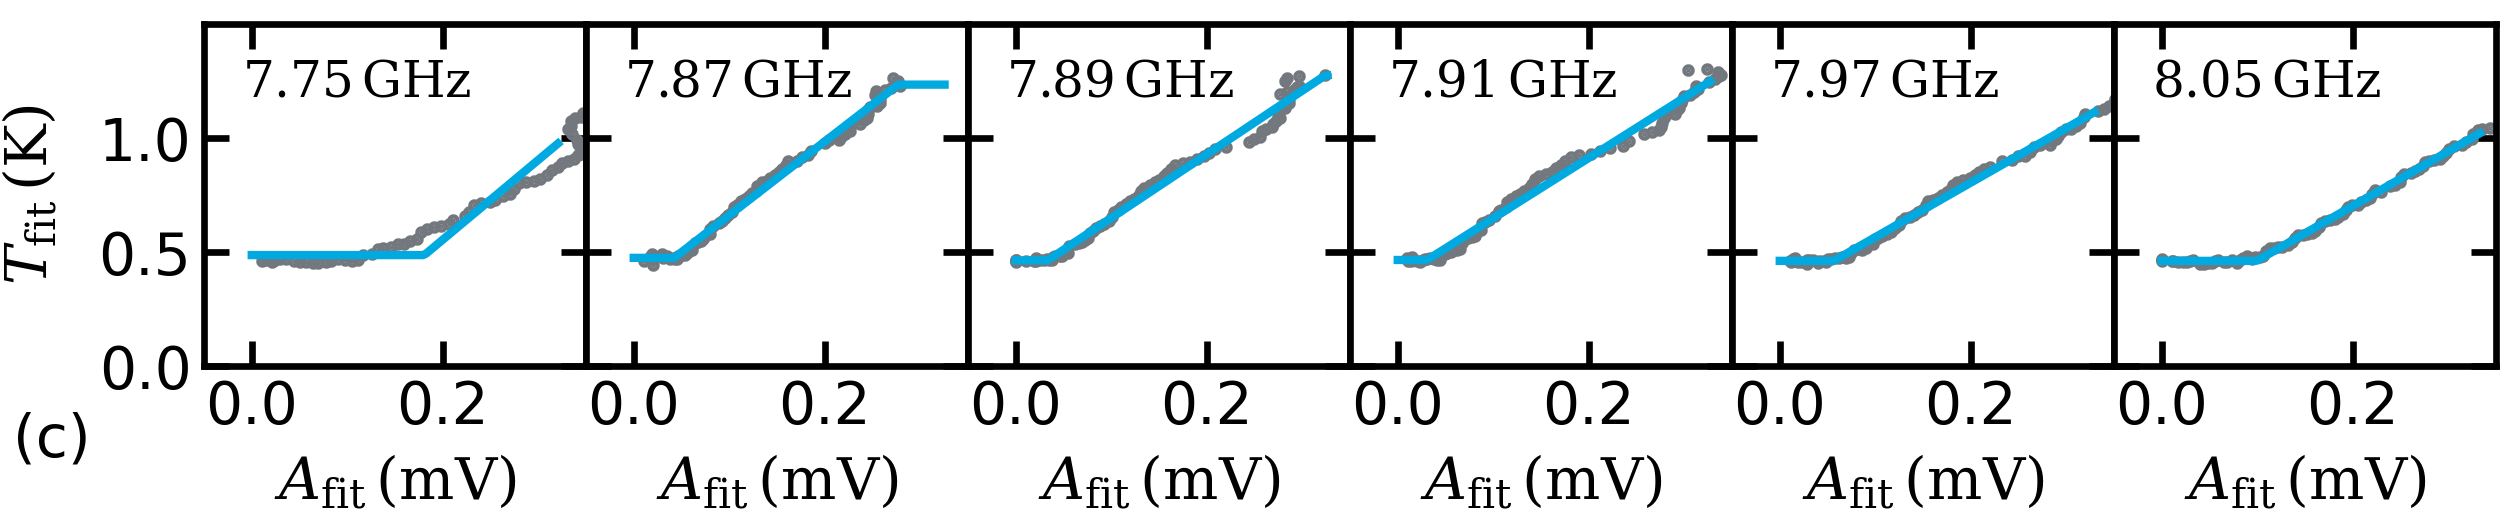

In [178]:
# Tfit_K(Afit_mV)
fig, axes = sc.get_figures(
    figsize=(4.2, 3.9 / 6 + 0.2),
    padding=(0.3, 0.2, 0.0, 0.0),
    nrows=1,
    ncols=6,
)
datafit = np.load(f"irradiation/fit.npz")
nu_GHz = datafit["nu_GHz"]
Acal = datafit["Acal"]
Tbase_Tfit_Afit = datafit["Tbase_Tfit_Afit"]
Tc_Tfit_Afit = datafit["Tc_Tfit_Afit"]
eta_Tfit_Afit = datafit["eta_Tfit_Afit"]
Toff_Tfit_Afit = datafit["Toff_Tfit_Afit"]

for i, nui_GHz in enumerate(nu_GHz[ii]):
    j = np.argmin(np.abs(nu_GHz - nui_GHz))

    datafit = np.load(f"irradiation/nu_{nui_GHz:3.2f}GHz/fit_data4.npz")
    Afit_mV = datafit["value_A_mV"]
    Tfit_K = datafit["value_T_K"]

    axes[i].plot(Afit_mV, Tfit_K, ".", color=sc.seegrau100)
    axes[i].plot(
        Acal * sc.h_pVs * nui_GHz,
        calibrate_T(
            Acal * sc.h_pVs * nui_GHz,
            Tbase_Tfit_Afit[j],
            Tc_Tfit_Afit[j],
            eta_Tfit_Afit[j],
            Toff_Tfit_Afit[j],
        ),
        "-",
        color=sc.seeblau100,
    )
    axes[i].set_xlim(-0.05, 0.35)
    axes[i].set_ylim(0.0, 1.5)
    axes[i].text(
        0.1,
        0.9,
        f"${nui_GHz:.2f}$" + "$\,\\mathrm{GHz}$",
        transform=axes[i].transAxes,
        ha="left",
        va="top",
        size=6,
    )

axes[0].text(
    -0.5,
    -0.3,
    "(c)",
    transform=axes[0].transAxes,
    ha="left",
    va="bottom",
    size=7,
)
sc.daumenkino_layout(
    fig,
    axes,
    title="tunnelbarrier/asym/irradiation/control/Tfit_Afit",
    ylabel="$T_\\mathrm{fit}\\,(\\mathrm{K})$",
    xlabel="$A_\\mathrm{fit}\\,(\\mathrm{mV})$",
    yticks=[0, 0.5, 1.0],
    xticks=[0, 0.2],
)
plt.show()

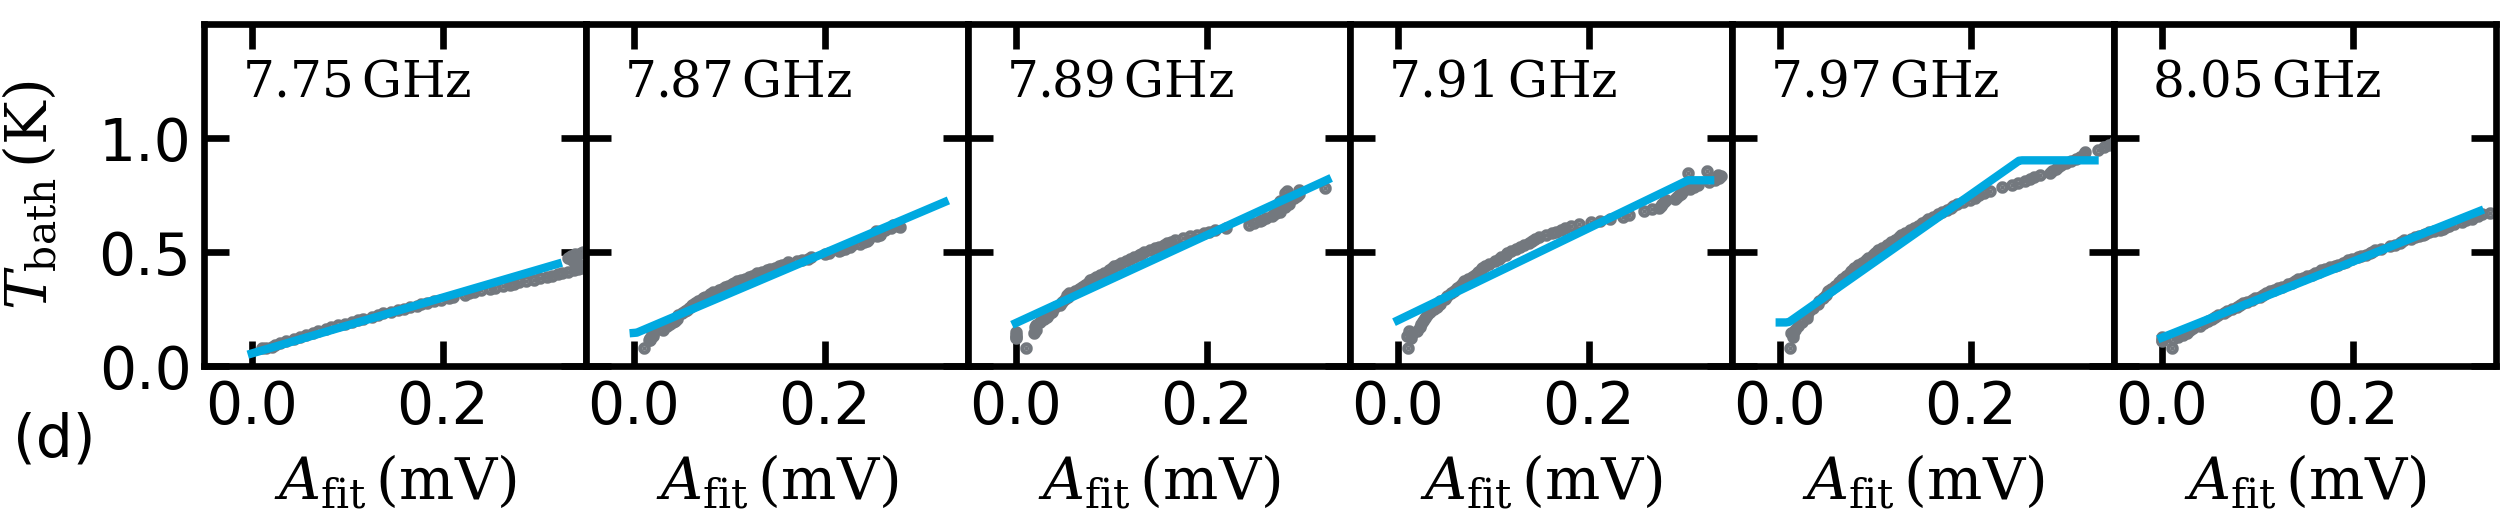

In [179]:
# Tbath_K(Afit_mV)
fig, axes = sc.get_figures(
    figsize=(4.2, 3.9 / 6 + 0.2),
    padding=(0.3, 0.2, 0.0, 0.0),
    nrows=1,
    ncols=6,
)
datafit = np.load(f"irradiation/fit.npz")
nu_GHz = datafit["nu_GHz"]
Tbase_Tbath_Afit = datafit["Tbase_Tbath_Afit"]
Tc_Tbath_Afit = datafit["Tc_Tbath_Afit"]
eta_Tbath_Afit = datafit["eta_Tbath_Afit"]
Toff_Tbath_Afit = datafit["Toff_Tbath_Afit"]

for i, nui_GHz in enumerate(nu_GHz[ii]):
    j = np.argmin(np.abs(nu_GHz - nui_GHz))

    datafit = np.load(f"irradiation/nu_{nui_GHz:3.2f}GHz/fit_data4.npz")
    Afit_mV = datafit["value_A_mV"]
    datafit = np.load(f"irradiation/nu_{nui_GHz:3.2f}GHz/eva.npz")
    Tbath_K = datafit["Tbath_K"]

    axes[i].plot(Afit_mV, Tbath_K, ".", color=sc.seegrau100)
    axes[i].plot(
        Acal * sc.h_pVs * nui_GHz,
        calibrate_T(
            Acal * sc.h_pVs * nui_GHz,
            Tbase_Tbath_Afit[j],
            Tc_Tbath_Afit[j],
            eta_Tbath_Afit[j],
            Toff_Tbath_Afit[j],
        ),
        "-",
        color=sc.seeblau100,
    )
    axes[i].set_xlim(-0.05, 0.35)
    axes[i].set_ylim(0.0, 1.5)
    axes[i].text(
        0.1,
        0.9,
        f"${nui_GHz:.2f}$" + "$\,\\mathrm{GHz}$",
        transform=axes[i].transAxes,
        ha="left",
        va="top",
        size=6,
    )

axes[0].text(
    -0.5,
    -0.3,
    "(d)",
    transform=axes[0].transAxes,
    ha="left",
    va="bottom",
    size=7,
)
sc.daumenkino_layout(
    fig,
    axes,
    title="tunnelbarrier/asym/irradiation/control/Tbath_Afit",
    ylabel="$T_\\mathrm{bath}\\,(\\mathrm{K})$",
    xlabel="$A_\\mathrm{fit}\\,(\\mathrm{mV})$",
    yticks=[0, 0.5, 1.0],
    xticks=[0, 0.2],
)
plt.show()

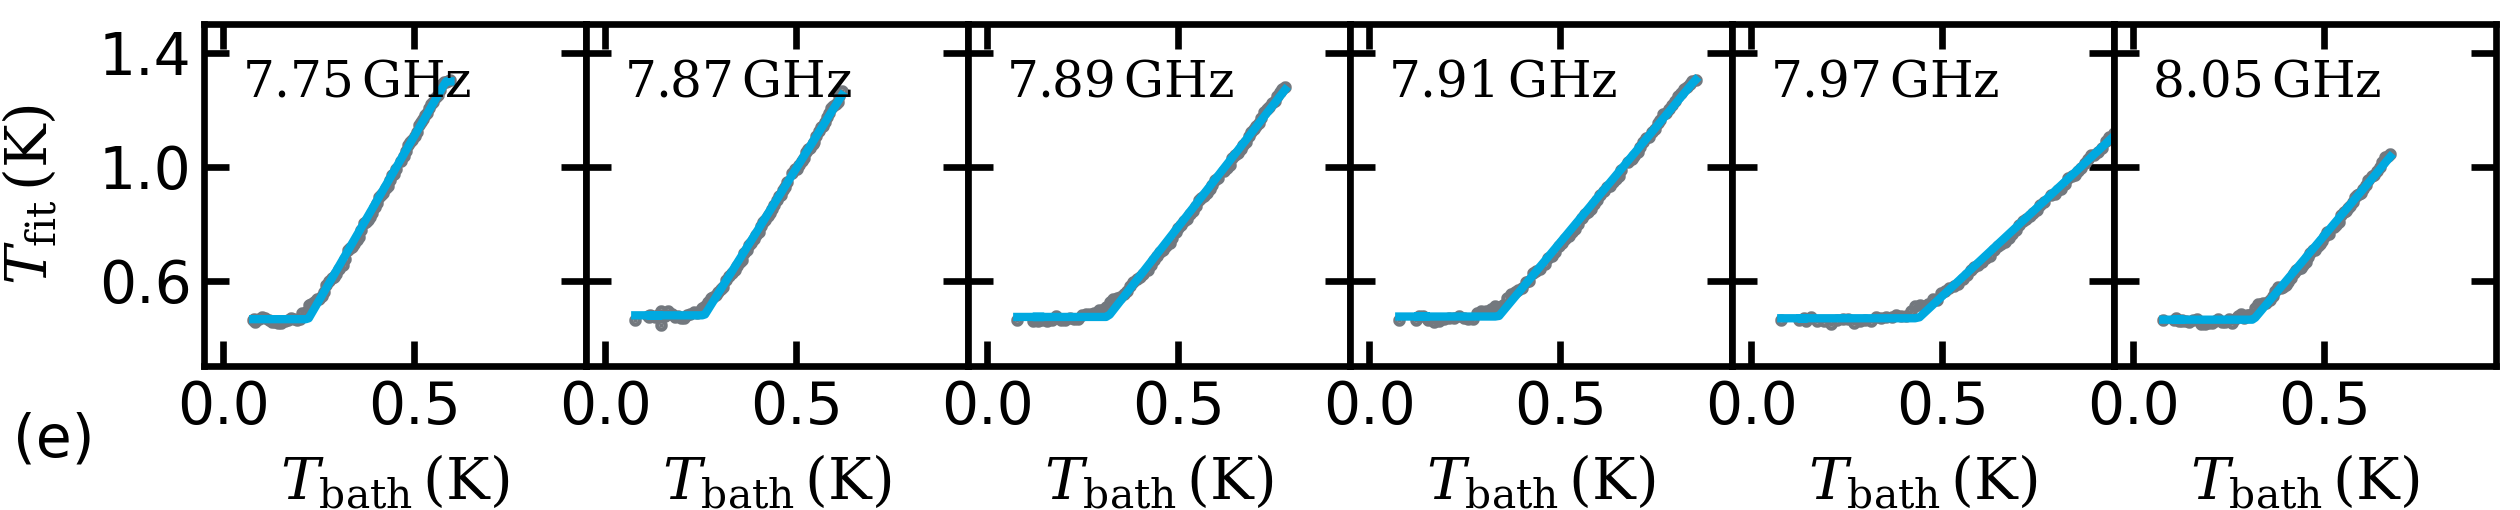

In [181]:
# Tfit_K(Tbath_K)
fig, axes = sc.get_figures(
    figsize=(4.2, 3.9 / 6 + 0.2),
    padding=(0.3, 0.2, 0.0, 0.0),
    nrows=1,
    ncols=6,
)
datafit = np.load(f"irradiation/fit.npz")
nu_GHz = datafit["nu_GHz"]
Tbase_Tfit_Tbath = datafit["Tbase_Tfit_Tbath"]
Tc_Tfit_Tbath = datafit["Tc_Tfit_Tbath"]
eta_Tfit_Tbath = datafit["eta_Tfit_Tbath"]
Toff_Tfit_Tbath = datafit["Toff_Tfit_Tbath"]


def calibrate_T(Aout_mV, Tbase_K, Tc_K, eta_T, Toff_K):
    return np.clip(eta_T * Aout_mV + Toff_K, Tbase_K, Tc_K)


for i, nui_GHz in enumerate(nu_GHz[ii]):
    j = np.argmin(np.abs(nu_GHz - nui_GHz))

    datafit = np.load(f"irradiation/nu_{nui_GHz:3.2f}GHz/fit_data4.npz")
    Tfit_K = datafit["value_T_K"]

    datafit = np.load(f"irradiation/nu_{nui_GHz:3.2f}GHz/eva.npz")
    Tbath_K = datafit["Tbath_K"]

    axes[i].plot(Tbath_K, Tfit_K, ".", color=sc.seegrau100)
    axes[i].plot(
        Tbath_K,
        calibrate_T(
            Tbath_K,
            Tbase_Tfit_Tbath[j],
            Tc_Tfit_Tbath[j],
            eta_Tfit_Tbath[j],
            Toff_Tfit_Tbath[j],
        ),
        "-",
        color=sc.seeblau100,
    )
    # axes[i].set_ylim(0.3, 1.5)
    # axes[i].set_xlim(-40, 840)
    axes[i].set_xlim(-0.05, 0.95)
    axes[i].set_ylim(0.3, 1.5)
    axes[i].text(
        0.1,
        0.9,
        f"${nui_GHz:.2f}$" + "$\,\\mathrm{GHz}$",
        transform=axes[i].transAxes,
        ha="left",
        va="top",
        size=6,
    )

axes[0].text(
    -0.5,
    -0.3,
    "(e)",
    transform=axes[0].transAxes,
    ha="left",
    va="bottom",
    size=7,
)
sc.daumenkino_layout(
    fig,
    axes,
    title="tunnelbarrier/asym/irradiation/control/Tfit_Tbath",
    xlabel="$T_\\mathrm{bath}\\,(\\mathrm{K})$",
    ylabel="$T_\\mathrm{fit}\\,(\\mathrm{K})$",
    xticks=[0, 0.5],
    yticks=[0.6, 1.0, 1.4],
    # yticks=[0.4, 0.8, 1.2],
)
plt.show()

# Fit Maps

In [85]:
# load data for Rectification Maps
from superconductivity.style.thesislayout import save_figure

datafit = np.load(f"irradiation/fit.npz")
nu_GHz = datafit["nu_GHz"]
Acal = datafit["Acal"]
ArectIexp = datafit["AI_Aout"]
ArectIcal = datafit["AI_Acal"]
ArectdGexp = datafit["AdG_Aout"]
ArectdGcal = datafit["AdG_Acal"]
ArectdRexp = datafit["AdR_Aout"]
ArectdRcal = datafit["AdR_Acal"]

dnu_GHz = (nu_GHz[1] - nu_GHz[0]) / 2
nulim = nu_GHz[3] - dnu_GHz, nu_GHz[-1] + dnu_GHz


dAcal = (Acal[1] - Acal[0]) / 2
Alim = Acal[0] - dAcal, Acal[-1] + dAcal

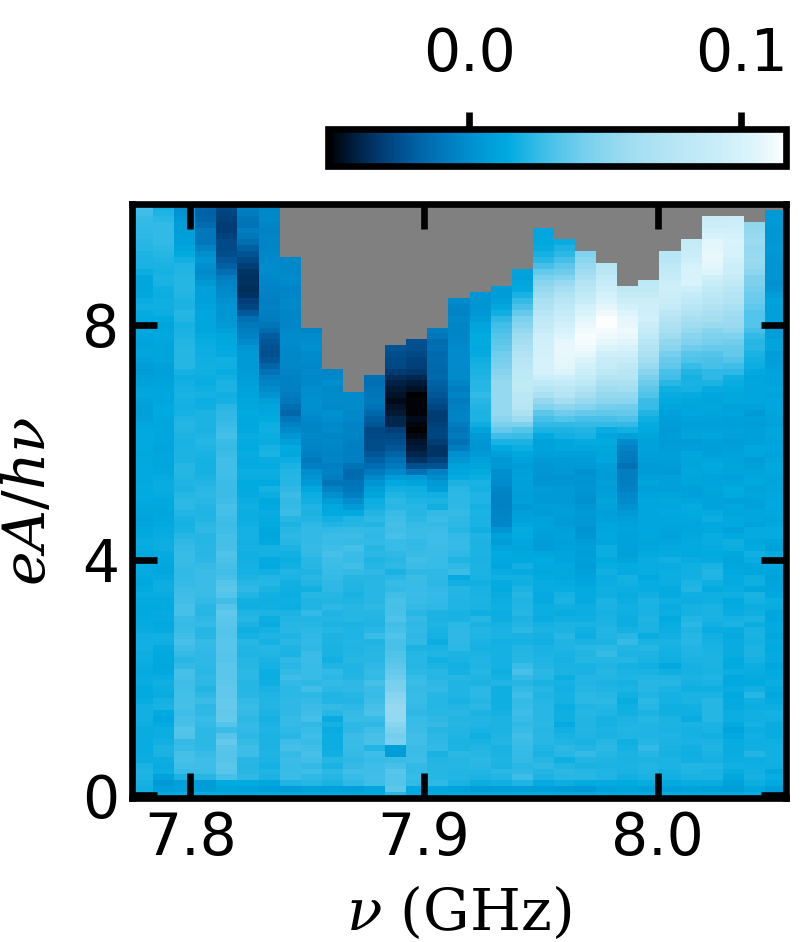

In [86]:
# rect I
fig, axes = sc.get_figures(
    figsize=(1.35, 1.57),
    padding=(0.18, 0.2, 0.0, 0.3),
    nrows=1,
    ncols=1,
)
ax = axes[0]

img = ax.imshow(
    (ArectIcal.T),
    aspect="auto",
    extent=(
        *nulim,
        *Alim,
    ),
    origin="lower",
    # clim=(-0.06, 0.11),
    cmap=sc.get_cmap(bad="grey"),
    zorder=-2,
    interpolation="None",
)

sc.daumenkino_layout(
    fig,
    axes,
    xlabel="$\\nu\\ (\\mathrm{GHz})$",
    ylabel="$eA/h\\nu$",
    yticks=[0, 4, 8],
)

upper_edge = max(ax.get_position().y1 for ax in axes)
left = max(ax.get_position().x0 for ax in axes)
right = min(ax.get_position().x1 for ax in axes)

width = right - left
shrink = 0.7
new_width = width * shrink
new_left = left + 0.25 * (width - new_width)
new_left = right - new_width

cax = fig.add_axes([new_left, upper_edge + 0.04, new_width, 0.04])

cbar = fig.colorbar(
    img,
    cax=cax,
    orientation="horizontal",
    # ticks=[0, 0.1],
)

cbar.ax.tick_params(
    labelsize=7,
    length=2,
    labelrotation=0,
    top=True,
    labeltop=True,
    bottom=False,
    labelbottom=False,
)


title = "tunnelbarrier/asym/irradiation/rect/iv"
save_figure(fig, title)
plt.show()

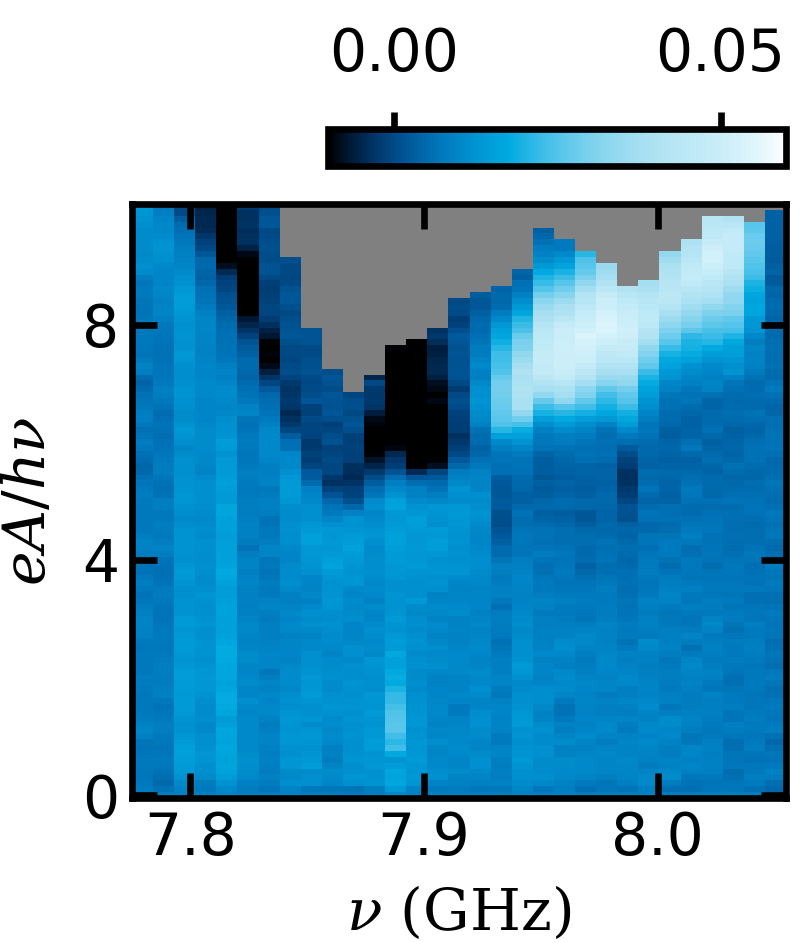

In [87]:
# rect dG
fig, axes = sc.get_figures(
    figsize=(1.35, 1.57),
    padding=(0.18, 0.2, 0.0, 0.3),
    nrows=1,
    ncols=1,
)
ax = axes[0]

img = ax.imshow(
    (ArectdGcal.T),
    aspect="auto",
    extent=(
        *nulim,
        *Alim,
    ),
    origin="lower",
    clim=(-0.01, 0.06),
    cmap=sc.get_cmap(bad="grey"),
    zorder=-2,
    interpolation="None",
)

sc.daumenkino_layout(
    fig,
    axes,
    xlabel="$\\nu\\ (\\mathrm{GHz})$",
    ylabel="$eA/h\\nu$",
    yticks=[0, 4, 8],
)

upper_edge = max(ax.get_position().y1 for ax in axes)
left = max(ax.get_position().x0 for ax in axes)
right = min(ax.get_position().x1 for ax in axes)

width = right - left
shrink = 0.7
new_width = width * shrink
new_left = left + 0.25 * (width - new_width)
new_left = right - new_width

cax = fig.add_axes([new_left, upper_edge + 0.04, new_width, 0.04])

cbar = fig.colorbar(
    img,
    cax=cax,
    orientation="horizontal",
    # ticks=[0, 0.1],
)

cbar.ax.tick_params(
    labelsize=7,
    length=2,
    labelrotation=0,
    top=True,
    labeltop=True,
    bottom=False,
    labelbottom=False,
)


title = "tunnelbarrier/asym/irradiation/rect/didv"
save_figure(fig, title)
plt.show()

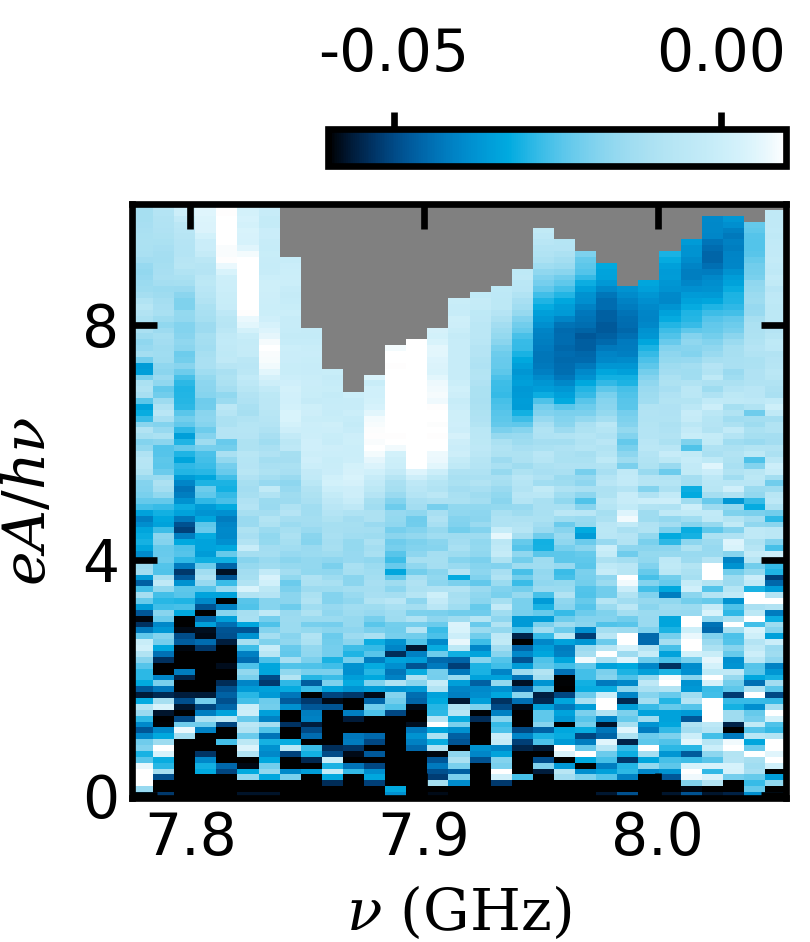

In [88]:
# rect dR
fig, axes = sc.get_figures(
    figsize=(1.35, 1.57),
    padding=(0.18, 0.2, 0.0, 0.3),
    nrows=1,
    ncols=1,
)
ax = axes[0]

img = ax.imshow(
    (ArectdRcal.T),
    aspect="auto",
    extent=(
        *nulim,
        *Alim,
    ),
    origin="lower",
    clim=(-0.06, 0.01),
    cmap=sc.get_cmap(bad="grey"),
    zorder=-2,
    interpolation="None",
)

sc.daumenkino_layout(
    fig,
    axes,
    xlabel="$\\nu\\ (\\mathrm{GHz})$",
    ylabel="$eA/h\\nu$",
    yticks=[0, 4, 8],
)

upper_edge = max(ax.get_position().y1 for ax in axes)
left = max(ax.get_position().x0 for ax in axes)
right = min(ax.get_position().x1 for ax in axes)

width = right - left
shrink = 0.7
new_width = width * shrink
new_left = left + 0.25 * (width - new_width)
new_left = right - new_width

cax = fig.add_axes([new_left, upper_edge + 0.04, new_width, 0.04])

cbar = fig.colorbar(
    img,
    cax=cax,
    orientation="horizontal",
    # ticks=[0, 0.1],
)

cbar.ax.tick_params(
    labelsize=7,
    length=2,
    labelrotation=0,
    top=True,
    labeltop=True,
    bottom=False,
    labelbottom=False,
)


title = "tunnelbarrier/asym/irradiation/rect/dvdi"
save_figure(fig, title)
plt.show()

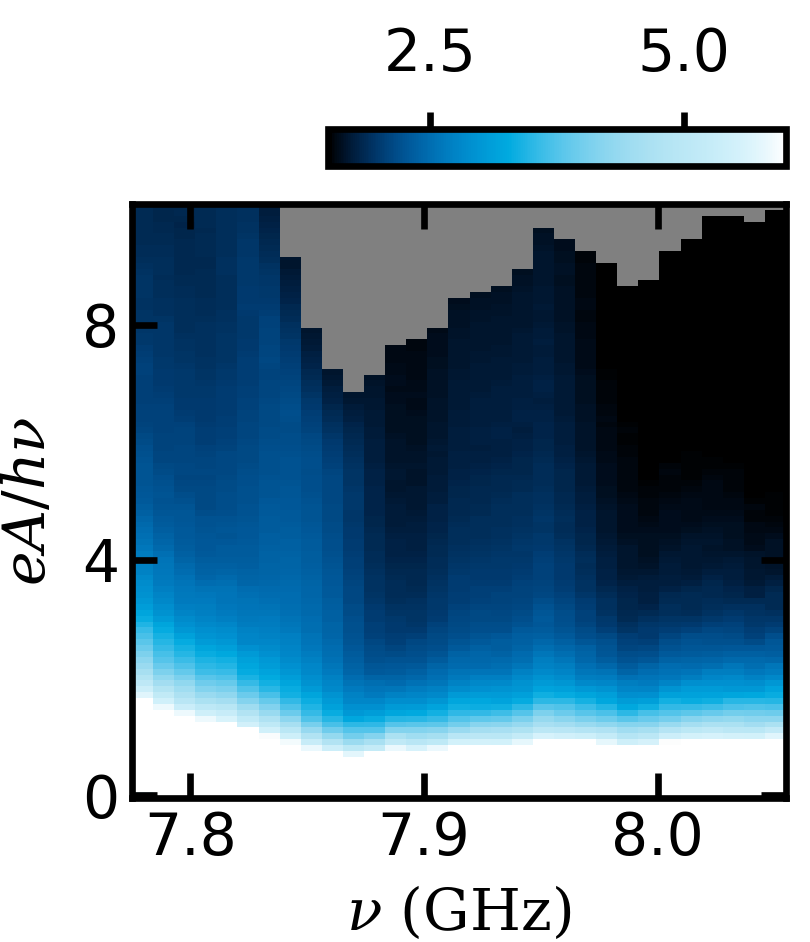

In [89]:
datafit = np.load(f"irradiation/fit.npz")
nu_GHz = datafit["nu_GHz"]
Aout_mV = datafit["Aout_mV"]
Tfit_Aout_K = datafit["Tfit_Aout_K"]
eta_Afit_Aout = datafit["eta_Afit_Aout"]
Acal = datafit["Acal"]

Aimg = np.divide(
    Tfit_Aout_K,
    Aout_mV * 1e-3,
    out=np.full_like(Tfit_Aout_K, 0.0, dtype=float),
    where=Aout_mV != 0.0,
)
# Aimg -=
# Aimg = Tfit_Aout_K
Aout = eta_Afit_Aout[:, np.newaxis] * Aout_mV / (sc.h_pVs * nu_GHz[:, np.newaxis])
Aimg = sc.nanbin_y_over_x(
    upsample(Aimg),
    upsample(Aout),
    Acal,
    axis=-1,
)

dnu_GHz = (nu_GHz[1] - nu_GHz[0]) / 2
nulim = nu_GHz[3] - dnu_GHz, nu_GHz[-1] + dnu_GHz

dAcal = (Acal[1] - Acal[0]) / 2
Alim = Acal[0] - dAcal, Acal[-1] + dAcal

fig, axes = sc.get_figures(
    figsize=(1.35, 1.57),
    padding=(0.18, 0.2, 0.0, 0.3),
    nrows=1,
    ncols=1,
)
ax = axes[0]

img = ax.imshow(
    (Aimg).T,
    aspect="auto",
    extent=(
        *nulim,
        *Alim,
    ),
    origin="lower",
    clim=(1.5, 6),
    cmap=sc.get_cmap(bad="grey"),
    zorder=-2,
    interpolation="None",
)
# ax.set_yticks([0, 5, 10],)

sc.daumenkino_layout(
    fig,
    axes,
    xlabel="$\\nu\\ (\\mathrm{GHz})$",
    ylabel="$eA/h\\nu$",
    yticks=[0, 4, 8],
)
upper_edge = max(ax.get_position().y1 for ax in axes)
left = max(ax.get_position().x0 for ax in axes)
right = min(ax.get_position().x1 for ax in axes)

width = right - left
shrink = 0.7
new_width = width * shrink
new_left = left + 0.25 * (width - new_width)
new_left = right - new_width

cax = fig.add_axes([new_left, upper_edge + 0.04, new_width, 0.04])

cbar = fig.colorbar(
    img,
    cax=cax,
    orientation="horizontal",
    # ticks=[0, 0.1],
)

# ax.text(
#     -0.15,
#     1.3,
#     "$\\frac{T_\\mathrm{fit}}{A_\\mathrm{out}}\\,\\left(\\frac{\\mathrm{K}}{\\mathrm{mV}}\\right)$",
#     transform=ax.transAxes,
#     ha="left",
#     va="top",
#     size=7,
# )
cbar.ax.tick_params(
    labelsize=7,
    length=2,
    labelrotation=0,
    top=True,
    labeltop=True,
    bottom=False,
    labelbottom=False,
)


title = "tunnelbarrier/asym/irradiation/control-img/Tfit_Aout"
save_figure(fig, title)
plt.show()

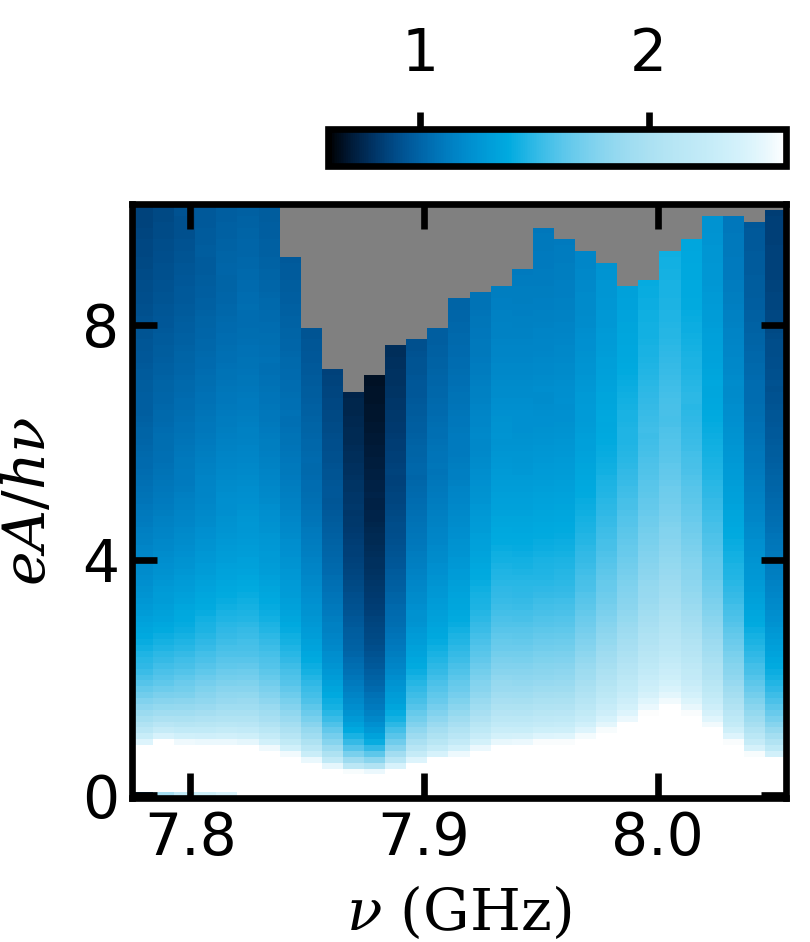

In [90]:
datafit = np.load(f"irradiation/fit.npz")
nu_GHz = datafit["nu_GHz"]
Aout_mV = datafit["Aout_mV"]
Tbath_Aout_K = datafit["Tbath_Aout_K"]
eta_Afit_Aout = datafit["eta_Afit_Aout"]
Acal = datafit["Acal"]

Aimg = np.divide(
    Tbath_Aout_K,
    Aout_mV * 1e-3,
    out=np.full_like(Tbath_Aout_K, 0.0, dtype=float),
    where=Aout_mV != 0.0,
)
# Aimg -=
# Aimg = Tfit_Aout_K
Aout = eta_Afit_Aout[:, np.newaxis] * Aout_mV / (sc.h_pVs * nu_GHz[:, np.newaxis])
Aimg = sc.nanbin_y_over_x(
    upsample(Aimg),
    upsample(Aout),
    Acal,
    axis=-1,
)

dnu_GHz = (nu_GHz[1] - nu_GHz[0]) / 2
nulim = nu_GHz[3] - dnu_GHz, nu_GHz[-1] + dnu_GHz

dAcal = (Acal[1] - Acal[0]) / 2
Alim = Acal[0] - dAcal, Acal[-1] + dAcal

fig, axes = sc.get_figures(
    figsize=(1.35, 1.57),
    padding=(0.18, 0.2, 0.0, 0.3),
    nrows=1,
    ncols=1,
)
ax = axes[0]

img = ax.imshow(
    (Aimg).T,
    aspect="auto",
    extent=(
        *nulim,
        *Alim,
    ),
    origin="lower",
    clim=(0.6, 2.6),
    cmap=sc.get_cmap(bad="grey"),
    zorder=-2,
    interpolation="None",
)
# ax.set_yticks([0, 5, 10],)

sc.daumenkino_layout(
    fig,
    axes,
    xlabel="$\\nu\\ (\\mathrm{GHz})$",
    ylabel="$eA/h\\nu$",
    yticks=[0, 4, 8],
)
upper_edge = max(ax.get_position().y1 for ax in axes)
left = max(ax.get_position().x0 for ax in axes)
right = min(ax.get_position().x1 for ax in axes)

width = right - left
shrink = 0.7
new_width = width * shrink
new_left = left + 0.25 * (width - new_width)
new_left = right - new_width

cax = fig.add_axes([new_left, upper_edge + 0.04, new_width, 0.04])

cbar = fig.colorbar(
    img,
    cax=cax,
    orientation="horizontal",
    # ticks=[0, 0.1],
)

# ax.text(
#     -0.15,
#     1.3,
#     "$\\frac{T_\\mathrm{bath}}{A_\\mathrm{out}}\\,\\left(\\frac{\\mathrm{K}}{\\mathrm{V}}\\right)$",
#     transform=ax.transAxes,
#     ha="left",
#     va="top",
#     size=7,
# )
cbar.ax.tick_params(
    labelsize=7,
    length=2,
    labelrotation=0,
    top=True,
    labeltop=True,
    bottom=False,
    labelbottom=False,
)


title = "tunnelbarrier/asym/irradiation/control-img/Tbath_Aout"
save_figure(fig, title)
plt.show()

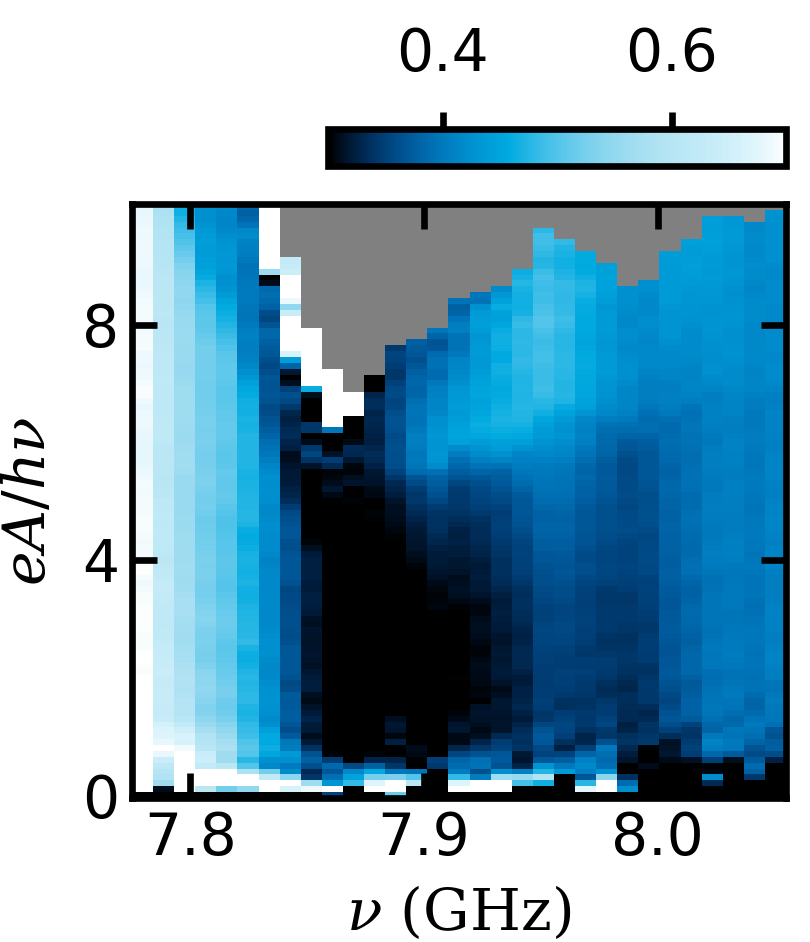

In [91]:
datafit = np.load(f"irradiation/fit.npz")
nu_GHz = datafit["nu_GHz"]
Aout_mV = datafit["Aout_mV"]
Afit_Aout_mV = datafit["Afit_Aout_mV"]
eta_Afit_Aout = datafit["eta_Afit_Aout"]
Acal = datafit["Acal"]

Aimg = np.divide(
    Afit_Aout_mV,
    Aout_mV,
    out=np.full_like(Afit_Aout_mV, 0.0, dtype=float),
    where=Aout_mV != 0.0,
)
Aout = eta_Afit_Aout[:, np.newaxis] * Aout_mV / (sc.h_pVs * nu_GHz[:, np.newaxis])
Aimg = sc.nanbin_y_over_x(
    upsample(Aimg),
    upsample(Aout),
    Acal,
    axis=-1,
)

dnu_GHz = (nu_GHz[1] - nu_GHz[0]) / 2
nulim = nu_GHz[3] - dnu_GHz, nu_GHz[-1] + dnu_GHz

dAcal = (Acal[1] - Acal[0]) / 2
Alim = Acal[0] - dAcal, Acal[-1] + dAcal

fig, axes = sc.get_figures(
    figsize=(1.35, 1.57),
    padding=(0.18, 0.2, 0.0, 0.3),
    nrows=1,
    ncols=1,
)
ax = axes[0]

img = ax.imshow(
    (Aimg).T * 1e3,
    aspect="auto",
    extent=(
        *nulim,
        *Alim,
    ),
    origin="lower",
    clim=(0.3, 0.7),
    cmap=sc.get_cmap(bad="grey"),
    zorder=-2,
    interpolation="None",
)
# ax.set_yticks([0, 5, 10],)

sc.daumenkino_layout(
    fig,
    axes,
    xlabel="$\\nu\\ (\\mathrm{GHz})$",
    ylabel="$eA/h\\nu$",
    yticks=[0, 4, 8],
)
upper_edge = max(ax.get_position().y1 for ax in axes)
left = max(ax.get_position().x0 for ax in axes)
right = min(ax.get_position().x1 for ax in axes)

width = right - left
shrink = 0.7
new_width = width * shrink
new_left = left + 0.25 * (width - new_width)
new_left = right - new_width

cax = fig.add_axes([new_left, upper_edge + 0.04, new_width, 0.04])

cbar = fig.colorbar(
    img,
    cax=cax,
    orientation="horizontal",
    # ticks=[0, 0.1],
)

# ax.text(
#     -0.15,
#     1.3,
#     "$\\frac{A_\\mathrm{fit}}{A_\\mathrm{out}}\\,(10^{-3})$",
#     transform=ax.transAxes,
#     ha="left",
#     va="top",
#     size=7,
# )
cbar.ax.tick_params(
    labelsize=7,
    length=2,
    labelrotation=0,
    top=True,
    labeltop=True,
    bottom=False,
    labelbottom=False,
)


title = "tunnelbarrier/asym/irradiation/control-img/Afit_Aout"
save_figure(fig, title)
plt.show()

# Frequency depending Parameter

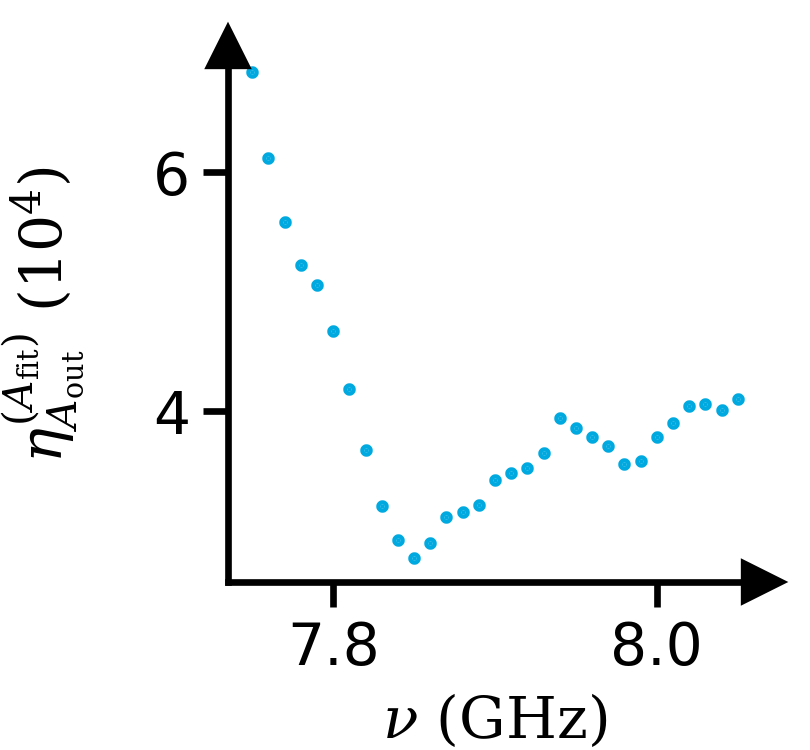

In [165]:
# eta_Afit_Aout over frequency
datafit = np.load(f"irradiation/fit.npz")
eta_Afit_Aout = datafit["eta_Afit_Aout"]
eta_Aout = datafit["eta_Aout"]
nu_GHz = datafit["nu_GHz"]

fig, ax = sc.get_figure(figsize=(1.35, 1.25), padding=(0.3, 0.2))

ax.plot(
    nu_GHz,
    eta_Afit_Aout * 1e4,
    ".",
    label="data",
    color=sc.seeblau100,
)
# ax.set_ylim(3.5, 9)

xlabel = "$\\nu\\ (\\mathrm{GHz})$"
ylabel = "$\\eta_{A_\\mathrm{out}}^{(A_\\mathrm{fit})}\\ (10^4)$"
title = f"tunnelbarrier/asym/irradiation/frequency/eta_Afit_Aout"

sc.theory_layout(fig, ax, title, xlabel, ylabel)

plt.show()

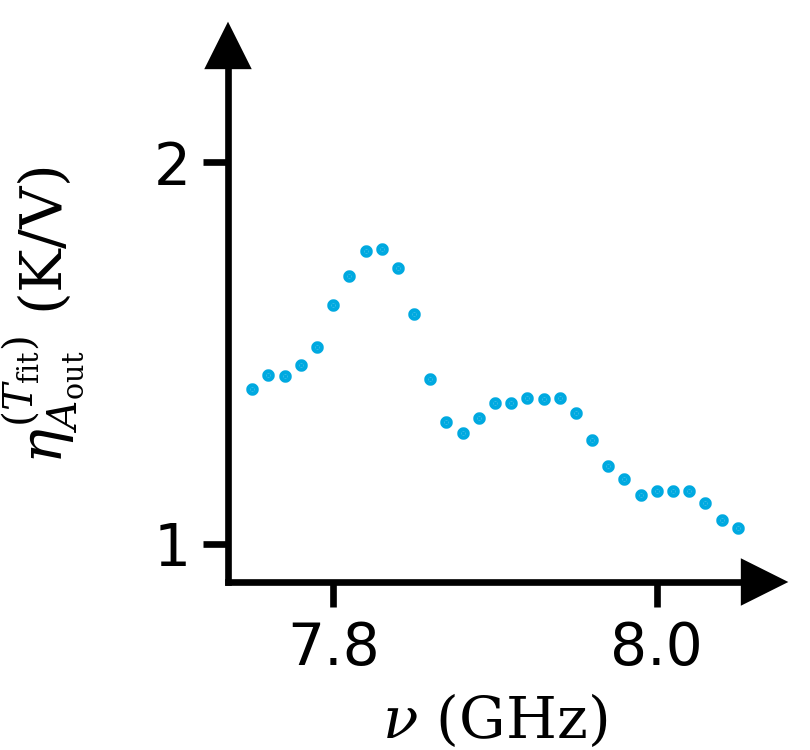

In [166]:
# eta_Tfit_Aout over frequency
datafit = np.load(f"irradiation/fit.npz")
nu_GHz = datafit["nu_GHz"]
eta_Tfit_Aout = datafit["eta_Tfit_Aout"]


fig, ax = sc.get_figure(figsize=(1.35, 1.25), padding=(0.3, 0.2))

ax.plot(
    nu_GHz,
    eta_Tfit_Aout * 1e3,
    ".",
    label="data",
    color=sc.seeblau100,
)
ax.set_ylim(0.9, 2.3)
# ax.set_yticks([1.0, 1.2, 1.4, 1.6])
ax.set_yticks([1, 2])

xlabel = "$\\nu\\ (\\mathrm{GHz})$"
ylabel = "$\\eta_{A_\\mathrm{out}}^{(T_\\mathrm{fit})}\\ (\\mathrm{K}/\\mathrm{V})$"
title = f"tunnelbarrier/asym/irradiation/frequency/eta_Tfit_Aout"

sc.theory_layout(fig, ax, title, xlabel, ylabel)
plt.show()

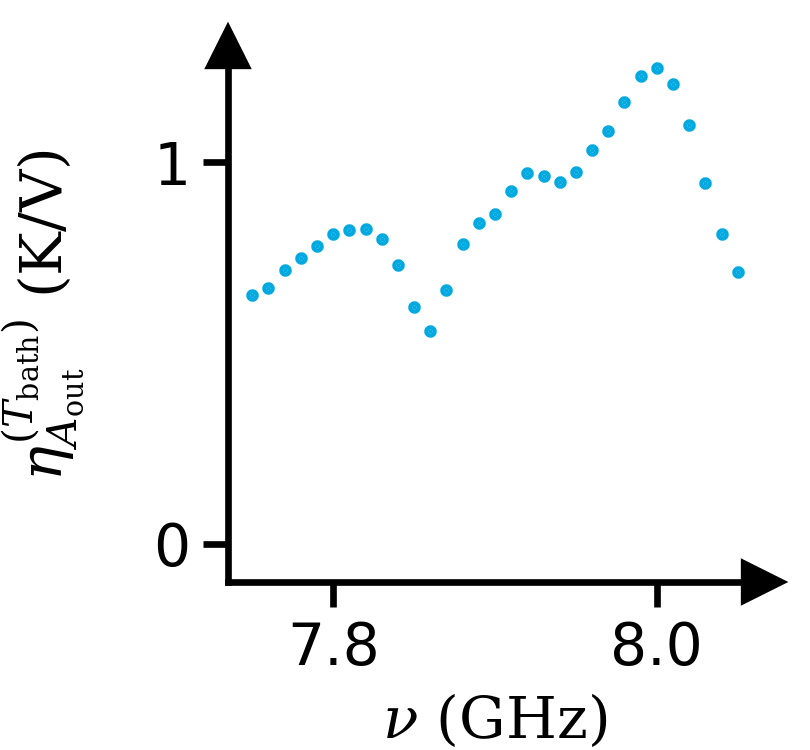

In [167]:
# eta_Tbath_Aout over frequency
datafit = np.load(f"irradiation/fit.npz")
nu_GHz = datafit["nu_GHz"]
eta_Tbath_Aout = datafit["eta_Tbath_Aout"]


fig, ax = sc.get_figure(figsize=(1.35, 1.25), padding=(0.3, 0.2))

ax.plot(
    nu_GHz,
    eta_Tbath_Aout * 1e3,
    ".",
    label="data",
    color=sc.seeblau100,
)
ax.set_ylim(-0.1, 1.3)
# ax.set_yticks([1.0, 1.2, 1.4, 1.6, 1.8])
ax.set_yticks([0, 1])

xlabel = "$\\nu\\ (\\mathrm{GHz})$"
ylabel = "$\\eta_{A_\\mathrm{out}}^{(T_\\mathrm{bath})}\\ (\\mathrm{K}/\\mathrm{V})$"
title = f"tunnelbarrier/asym/irradiation/frequency/eta_Tbath_Aout"

sc.theory_layout(fig, ax, title, xlabel, ylabel)
plt.show()

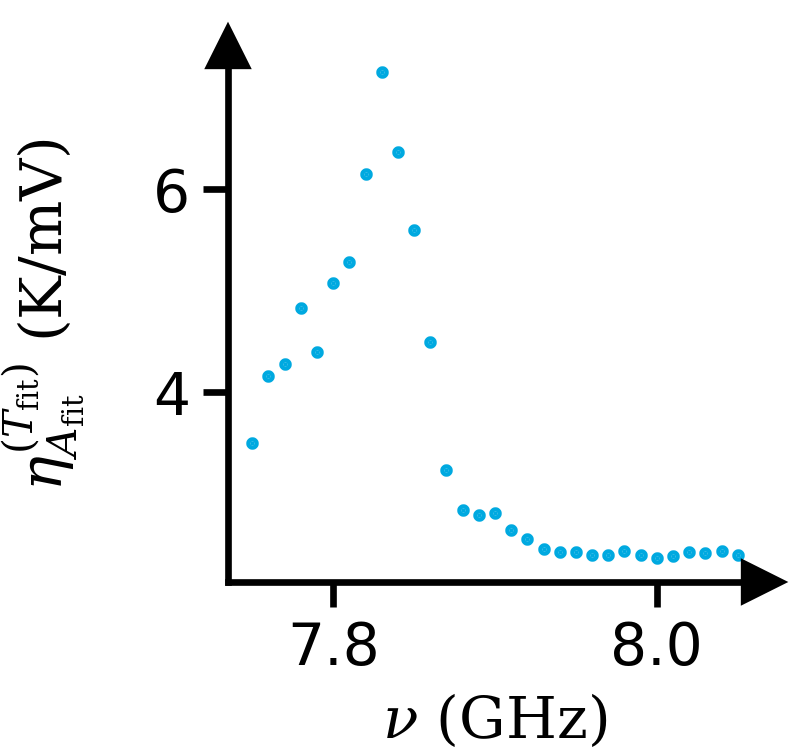

In [168]:
# eta_Tfit_Afit over frequency
datafit = np.load(f"irradiation/fit.npz")
nu_GHz = datafit["nu_GHz"]
eta_Tfit_Afit = datafit["eta_Tfit_Afit"]


fig, ax = sc.get_figure(figsize=(1.35, 1.25), padding=(0.3, 0.2))

ax.plot(
    nu_GHz,
    eta_Tfit_Afit,
    ".",
    label="data",
    color=sc.seeblau100,
)
# ax.set_ylim(0.9, 1.9)
# ax.set_yticks([1.0, 1.2, 1.4, 1.6, 1.8])

xlabel = "$\\nu\\ (\\mathrm{GHz})$"
ylabel = "$\\eta_{A_\\mathrm{fit}}^{(T_\\mathrm{fit})}\\ (\\mathrm{K}/\\mathrm{mV})$"
title = f"tunnelbarrier/asym/irradiation/frequency/eta_Tfit_Afit"

sc.theory_layout(fig, ax, title, xlabel, ylabel)

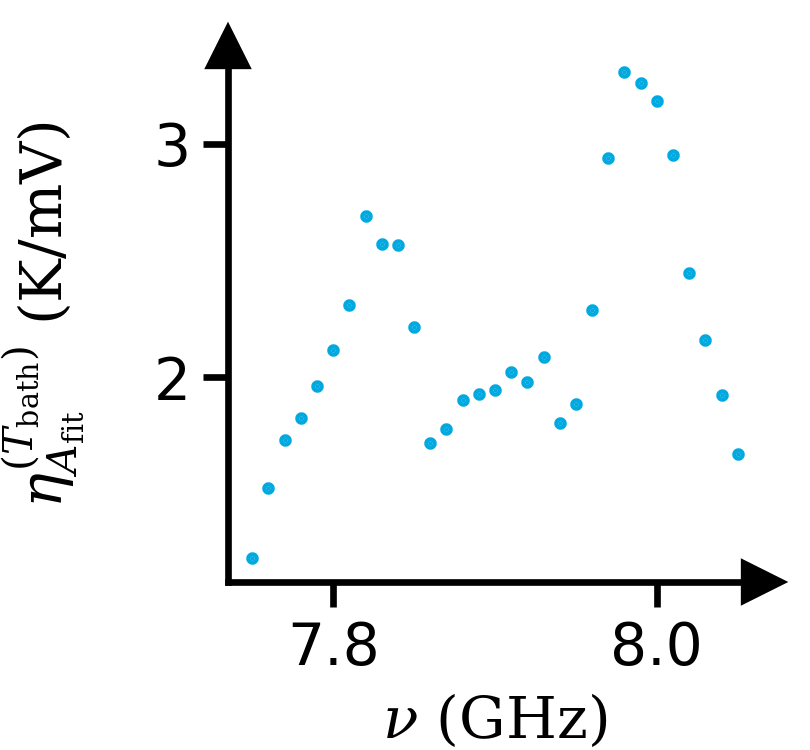

In [169]:
# eta_Tbath_Afit over frequency
datafit = np.load(f"irradiation/fit.npz")
nu_GHz = datafit["nu_GHz"]
eta_Tbath_Afit = datafit["eta_Tbath_Afit"]


fig, ax = sc.get_figure(figsize=(1.35, 1.25), padding=(0.3, 0.2))

ax.plot(
    nu_GHz,
    eta_Tbath_Afit,
    ".",
    label="data",
    color=sc.seeblau100,
)
# ax.set_ylim(0.9, 1.9)
# ax.set_yticks([1.0, 1.2, 1.4, 1.6, 1.8])

xlabel = "$\\nu\\ (\\mathrm{GHz})$"
ylabel = "$\\eta_{A_\\mathrm{fit}}^{(T_\\mathrm{bath})}\\ (\\mathrm{K}/\\mathrm{mV})$"
title = f"tunnelbarrier/asym/irradiation/frequency/eta_Tbath_Afit"

sc.theory_layout(fig, ax, title, xlabel, ylabel)

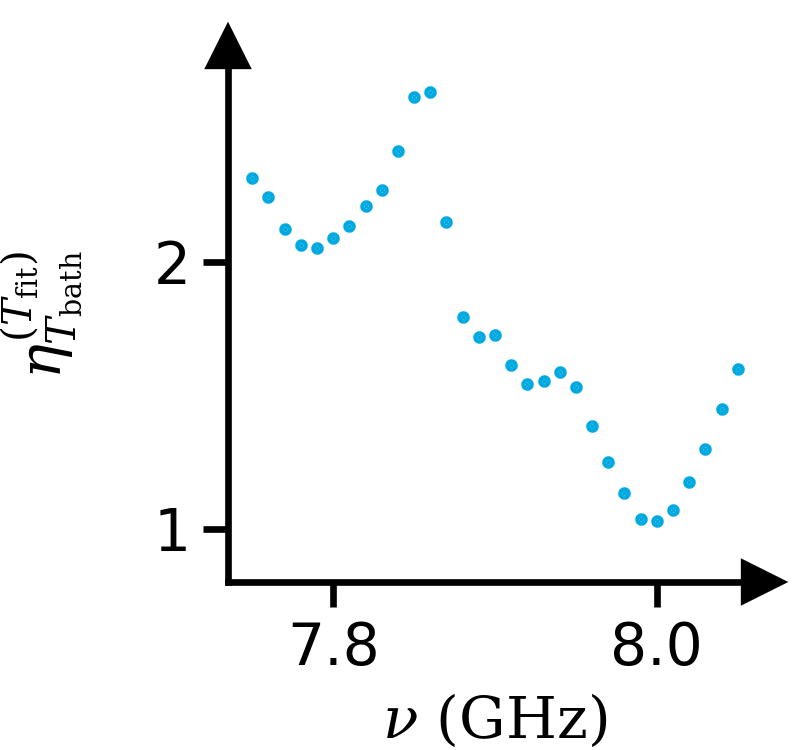

In [170]:
# eta_Tfit_Tbath over frequency
datafit = np.load(f"irradiation/fit.npz")
nu_GHz = datafit["nu_GHz"]
eta_Tfit_Tbath = datafit["eta_Tfit_Tbath"]


fig, ax = sc.get_figure(figsize=(1.35, 1.25), padding=(0.3, 0.2))

ax.plot(
    nu_GHz,
    eta_Tfit_Tbath,
    ".",
    label="data",
    color=sc.seeblau100,
)
ax.set_ylim(0.8, 2.8)
# ax.set_yticks([1.0, 1.2, 1.4, 1.6, 1.8])
ax.set_yticks([1, 2])

xlabel = "$\\nu\\ (\\mathrm{GHz})$"
ylabel = "$\\eta_{T_\\mathrm{bath}}^{(T_\\mathrm{fit})}$"
title = f"tunnelbarrier/asym/irradiation/frequency/eta_Tfit_Tbath"

sc.theory_layout(fig, ax, title, xlabel, ylabel)
plt.show()

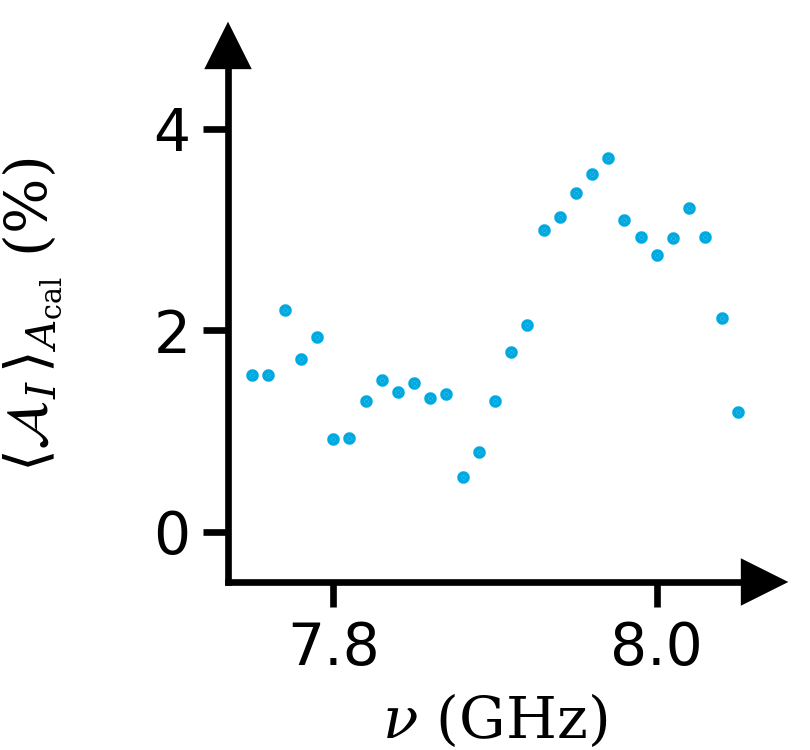

In [98]:
# rectA over frequency
datafit = np.load(f"irradiation/fit.npz")
nu_GHz = datafit["nu_GHz"]
ArectIcal = datafit["AI_Acal"]
ArectdGcal = datafit["AdG_Acal"]
ArectdRcal = datafit["AdR_Acal"]

fig, ax = sc.get_figure(figsize=(1.35, 1.25), padding=(0.3, 0.2))
for i, nui_GHz in enumerate(nu_GHz):

    valid_I = np.isfinite(ArectIcal[i, :])
    valid_dG = np.isfinite(ArectdGcal[i, :])
    valid_dR = np.isfinite(ArectdRcal[i, :])
    AI = np.trapezoid(ArectIcal[i, valid_I], Acal[valid_I]) / (
        np.max(Acal[valid_I]) - np.min(Acal[valid_I])
    )
    AdG = np.trapezoid((ArectdGcal[i, valid_dG]), Acal[valid_dG]) / (
        np.max(Acal[valid_dG]) - np.min(Acal[valid_dG])
    )
    AdR = np.trapezoid((ArectdRcal[i, valid_dR]), Acal[valid_dR]) / (
        np.max(Acal[valid_dR]) - np.min(Acal[valid_dR])
    )
    ax.plot(nui_GHz, AI * 1e2, ".", color=sc.seeblau100)

xlabel = "$\\nu\\ (\\mathrm{GHz})$"
ylabel = "$\\mathcal{A}$"
ylabel = "$\\langle \\mathcal{A}_{I}\\, \\rangle_{A_\\mathrm{cal}}\\ (\\%)$"
title = f"tunnelbarrier/asym/irradiation/frequency/rectI"
ax.set_ylim(-0.5, 4.8)
# ax.set_yticks([0.0, 0.1, 0.2, 0.3])
sc.theory_layout(fig, ax, title, xlabel, ylabel)

plt.show()

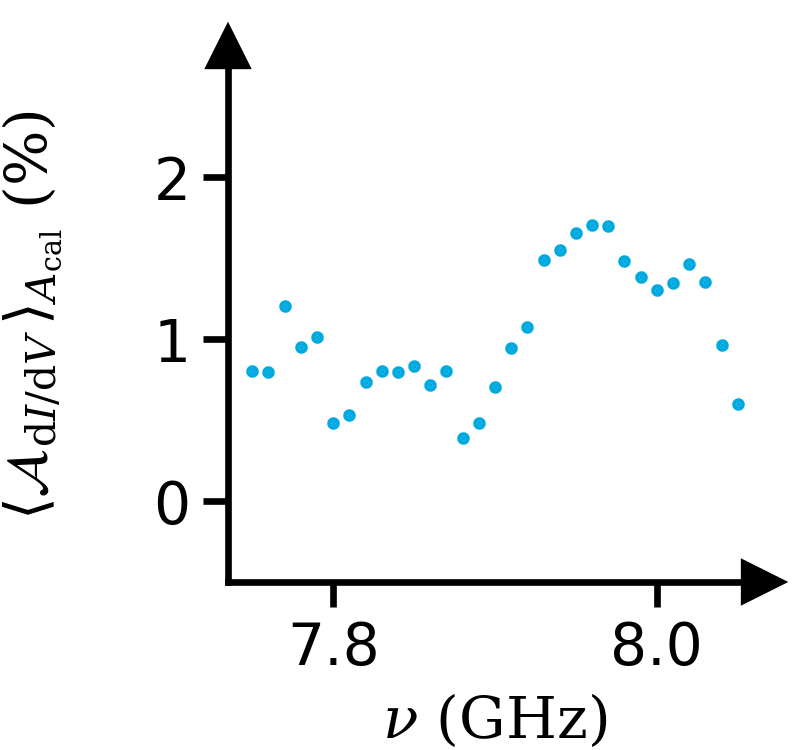

In [99]:
# rectdG over frequency
datafit = np.load(f"irradiation/fit.npz")
nu_GHz = datafit["nu_GHz"]
ArectIcal = datafit["AI_Acal"]
ArectdGcal = datafit["AdG_Acal"]
ArectdRcal = datafit["AdR_Acal"]

fig, ax = sc.get_figure(figsize=(1.35, 1.25), padding=(0.3, 0.2))
for i, nui_GHz in enumerate(nu_GHz):

    valid_I = np.isfinite(ArectIcal[i, :])
    valid_dG = np.isfinite(ArectdGcal[i, :])
    valid_dR = np.isfinite(ArectdRcal[i, :])
    AI = np.trapezoid(ArectIcal[i, valid_I], Acal[valid_I]) / (
        np.max(Acal[valid_I]) - np.min(Acal[valid_I])
    )
    AdG = np.trapezoid((ArectdGcal[i, valid_dG]), Acal[valid_dG]) / (
        np.max(Acal[valid_dG]) - np.min(Acal[valid_dG])
    )
    AdR = np.trapezoid((ArectdRcal[i, valid_dR]), Acal[valid_dR]) / (
        np.max(Acal[valid_dR]) - np.min(Acal[valid_dR])
    )
    ax.plot(nui_GHz, AdG * 1e2, ".", color=sc.seeblau100)

xlabel = "$\\nu\\ (\\mathrm{GHz})$"
ylabel = "$\\langle \\mathcal{A}_{\\mathrm{d}I/\\mathrm{d}V}\\, \\rangle_{A_\\mathrm{cal}}\\ (\\%)$"
title = f"tunnelbarrier/asym/irradiation/frequency/rectdG"
ax.set_ylim(-0.5, 2.8)
# ax.set_yticks([0, 0.1, 0.2])
sc.theory_layout(fig, ax, title, xlabel, ylabel)

plt.show()

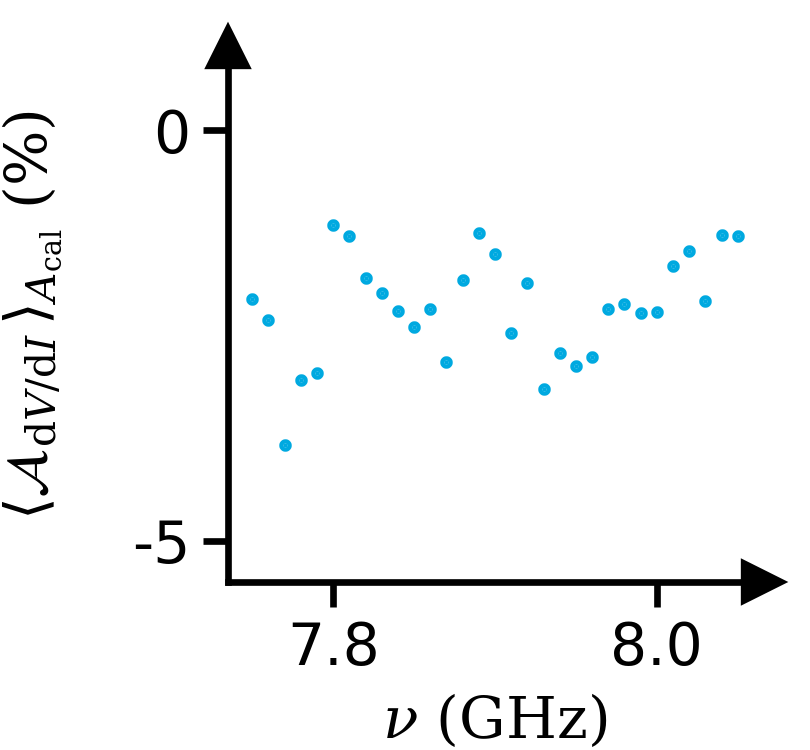

In [100]:
# rectdR over frequency
datafit = np.load(f"irradiation/fit.npz")
nu_GHz = datafit["nu_GHz"]
ArectIcal = datafit["AI_Acal"]
ArectdGcal = datafit["AdG_Acal"]
ArectdRcal = datafit["AdR_Acal"]

fig, ax = sc.get_figure(figsize=(1.35, 1.25), padding=(0.3, 0.2))
for i, nui_GHz in enumerate(nu_GHz):

    valid_I = np.isfinite(ArectIcal[i, :])
    valid_dG = np.isfinite(ArectdGcal[i, :])
    valid_dR = np.isfinite(ArectdRcal[i, :])
    AI = np.trapezoid(ArectIcal[i, valid_I], Acal[valid_I]) / (
        np.max(Acal[valid_I]) - np.min(Acal[valid_I])
    )
    AdG = np.trapezoid((ArectdGcal[i, valid_dG]), Acal[valid_dG]) / (
        np.max(Acal[valid_dG]) - np.min(Acal[valid_dG])
    )
    AdR = np.trapezoid((ArectdRcal[i, valid_dR]), Acal[valid_dR]) / (
        np.max(Acal[valid_dR]) - np.min(Acal[valid_dR])
    )
    ax.plot(nui_GHz, AdR * 1e2, ".", color=sc.seeblau100)

xlabel = "$\\nu\\ (\\mathrm{GHz})$"
ylabel = "$\\langle \\mathcal{A}_{\\mathrm{d}V/\\mathrm{d}I}\\, \\rangle_{A_\\mathrm{cal}}\\ (\\%)$"
title = f"tunnelbarrier/asym/irradiation/frequency/rectdR"
ax.set_ylim(-5.5, 1)
ax.set_yticks([-5, 0.00])
sc.theory_layout(fig, ax, title, xlabel, ylabel)

plt.show()

In [101]:
# # rectification over frequency
# datafit = np.load(f"irradiation/fit.npz")
# nu_GHz = datafit["nu_GHz"]
# Acal = datafit["Acal"]
# ArectIcal = datafit["AI_Acal"]
# ArectdGcal = datafit["AdG_Acal"]
# ArectdRcal = datafit["AdR_Acal"]

# fig, ax = sc.get_figure(figsize=(1.35, 1.2), padding=(0.35, 0.2))
# for i, nui_GHz in enumerate(nu_GHz):

#     valid_I = np.isfinite(ArectIcal[i, :])
#     valid_dG = np.isfinite(ArectdGcal[i, :])
#     valid_dR = np.isfinite(ArectdRcal[i, :])
#     AI = np.trapezoid(ArectIcal[i, valid_I], Acal[valid_I])
#     AdG = np.trapezoid(ArectdGcal[i, valid_dG], Acal[valid_dG])
#     AdR = np.trapezoid(ArectdRcal[i, valid_dR], Acal[valid_dR])
#     ax.plot(nui_GHz, AI, ".", color=sc.seeblau100)
#     ax.plot(nui_GHz, AdG, ".", color=sc.seeblau35)
#     ax.plot(nui_GHz, AdR, ".", color=sc.seegrau35)

# ax.plot([], [], ".", color=sc.seeblau100, label="$I$")
# ax.plot([], [], ".", color=sc.seeblau35, label="$\\mathrm{d}I/\\mathrm{d}V$")
# ax.plot([], [], ".", color=sc.seegrau35, label="$\\mathrm{d}V/\\mathrm{d}I$")
# ax.legend(
#     # title="$\\alpha_q = $",
#     handlelength=1.2,
#     loc="upper right",
#     frameon=False,
#     fontsize=6,
#     title_fontsize=6,
#     ncols=1,
#     columnspacing=0.8,
#     borderpad=0.1,  # reduces padding inside the legend box
#     labelspacing=0.3,  # reduces vertical spacing between items
#     handletextpad=0.8,  # reduces spacing between line and label
#     bbox_to_anchor=(1.1, 1.1),
# )
# xlabel = "$\\nu\\ (\\mathrm{GHz})$"
# ylabel = "$\\langle \\mathcal{A}\\, \\rangle_\\alpha$"
# title = f"tunnelbarrier/asym/irradiation/frequency/rect-Acal"
# ax.set_ylim(-0.6, 1.2)
# # ax.set_yticks([-1, 0, 1])
# sc.theory_layout(fig, ax, title, xlabel, ylabel)

# plt.show()

In [102]:
# # rectification over frequency
# datafit = np.load(f"irradiation/fit.npz")
# nu_GHz = datafit["nu_GHz"]
# Aout_mV = datafit["Aout_mV"]
# ArectIcal = datafit["AI_Aout"]
# ArectdGcal = datafit["AdG_Aout"]
# ArectdRcal = datafit["AdR_Aout"]

# fig, ax = sc.get_figure(figsize=(1.35, 1.25), padding=(0.3, 0.2))
# for i, nui_GHz in enumerate(nu_GHz):
#     Acal = Aout_mV / (sc.h_pVs * nui_GHz)

#     valid_I = np.isfinite(ArectIcal[i, :])
#     valid_dG = np.isfinite(ArectdGcal[i, :])
#     valid_dR = np.isfinite(ArectdRcal[i, :])
#     AI = np.trapezoid(ArectIcal[i, valid_I], Acal[valid_I])
#     AdG = np.trapezoid(ArectdGcal[i, valid_dG], Acal[valid_dG])
#     AdR = np.trapezoid(ArectdRcal[i, valid_dR], Acal[valid_dR])
#     ax.plot(nui_GHz, AI * 1.0e-3, ".", color=sc.seeblau100)
#     ax.plot(nui_GHz, AdG * 1.0e-3, ".", color=sc.seeblau35)
#     ax.plot(nui_GHz, AdR * 1.0e-3, ".", color=sc.seegrau35)

# ax.plot([], [], ".", color=sc.seeblau100, label="$I$")
# ax.plot([], [], ".", color=sc.seeblau35, label="$\\mathrm{d}I/\\mathrm{d}V$")
# ax.plot([], [], ".", color=sc.seegrau35, label="$\\mathrm{d}V/\\mathrm{d}I$")
# ax.legend(
#     # title="$\\alpha_q = $",
#     handlelength=1.2,
#     loc="upper right",
#     frameon=False,
#     fontsize=6,
#     title_fontsize=6,
#     ncols=1,
#     columnspacing=0.8,
#     borderpad=0.1,  # reduces padding inside the legend box
#     labelspacing=0.3,  # reduces vertical spacing between items
#     handletextpad=0.8,  # reduces spacing between line and label
#     bbox_to_anchor=(1.1, 1.1),
# )
# xlabel = "$\\nu\\ (\\mathrm{GHz})$"
# ylabel = "$\\int \\mathcal{A}\\, \\mathrm{d}\\alpha/\\eta \\ (10^3)$"
# ax.set_ylim(-1.2, 2.4)
# # ax.set_yticks([-1, 0, 1])
# sc.theory_layout(fig, ax, title, xlabel, ylabel)

# plt.show()